In [10]:
library(riboWaltz)
library(Rsamtools)
library(GenomicFeatures)
library(GenomicRanges)
library(tidyverse)
library(ggplot2)


In [11]:
cds <- create_annotation(gtfpath='/store24/project24/ladcol_002/riboseq/reference_genome/gencode.vM35.annotation.gtf', dataSource = "gencode", organism = "Mus musculus")

Warning message in call_fun_in_txdbmaker("makeTxDbFromGFF", ...):
“makeTxDbFromGFF() has moved to the txdbmaker package. Please call
  txdbmaker::makeTxDbFromGFF() to get rid of this warning.”
Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK



In [12]:
reads_list <- bamtolist(
  bamfolder = '/store24/project24/ladcol_002/jupyter_interactive/riboseq/bam_files',
  annotation = cds
)


Reading extract_B73_1_1.bam
Input reads: 51.179 M
Good! Number of indel below indel_threshold for all reads. No reads removed.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.601 M  (1.175 %) reads removed: mapping on negative strand.
Output reads: 50.577 M
Done! extract_B73_1_1.bam has been loaded as extract_B73_1_1 

Reading extract_B73_2_1.bam
Input reads: 23.251 M
Good! Number of indel below indel_threshold for all reads. No reads removed.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.324 M  (1.395 %) reads removed: mapping on negative strand.
Output reads: 22.927 M
Done! extract_B73_2_1.bam has been loaded as extract_B73_2_1 

Reading extract_B73_3_1.bam
Input reads: 20.269 M
Good! Number of indel below indel_threshold for all reads. No reads removed.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.256 M  (1.261 %) reads removed

In [13]:
# remove duplicates
filtered_list <- duplicates_filter(data = reads_list,
 				    extremity = "both")
filtered_list[["Samp_example"]]

processing extract_B73_1_1
reads: 50.580 M
45.150 M  (89.270 %) reads removed
reads kept: 5.430 M

processing extract_B73_2_1
reads: 22.930 M
22.140 M  (96.570 %) reads removed
reads kept: 0.790 M

processing extract_B73_3_1
reads: 20.010 M
19.170 M  (95.770 %) reads removed
reads kept: 0.850 M

processing extract_B73_4_1
reads: 13.710 M
13.420 M  (97.870 %) reads removed
reads kept: 0.290 M



NULL

In [15]:
library(dplyr)

combined_df <- bind_rows(
  lapply(names(filtered_list), function(nm) {
    df <- reads_list[[nm]]
    df$Sample <- nm   # add a column with sample name
    return(df)
  })
)

# Periodicity threshold mode

In [18]:
filtered_list_th <- length_filter(data = filtered_list,
 				length_filter_mode = "periodicity",
 				periodicity_threshold = 40)

processing extract_B73_1_1
reads: 5.43 M
0.83 M  (15.37 %) reads removed
reads (kept): 4.59 M

processing extract_B73_2_1
reads: 0.79 M
0.23 M  (28.68 %) reads removed
reads (kept): 0.56 M

processing extract_B73_3_1
reads: 0.85 M
0.14 M  (16.26 %) reads removed
reads (kept): 0.71 M

processing extract_B73_4_1
reads: 0.29 M
0.07 M  (25.52 %) reads removed
reads (kept): 0.22 M



# manual mode filtering - to filter read length

In [19]:
 filtered_list_manual <- length_filter(data = filtered_list_th,
 			        length_filter_mode = "custom",
 				length_range = 26:32) # consider a range of 26 to 32 - initial range 29:30


processing extract_B73_1_1
reads: 4.59 M
2.42 M  (52.63 %) reads removed
reads (kept): 2.17 M

processing extract_B73_2_1
reads: 0.56 M
0.31 M  (55.32 %) reads removed
reads (kept): 0.25 M

processing extract_B73_3_1
reads: 0.71 M
0.38 M  (53.27 %) reads removed
reads (kept): 0.33 M

processing extract_B73_4_1
reads: 0.22 M
0.12 M  (52.84 %) reads removed
reads (kept): 0.10 M



# P-site offset

In [22]:
psite_offset_thr <- psite(filtered_list_manual, flanking = 6, extremity = "auto")

processing extract_B73_1_1
best offset: 13 nts from the 5' end
processing extract_B73_2_1
best offset: 13 nts from the 5' end
processing extract_B73_3_1
best offset: 13 nts from the 5' end
processing extract_B73_4_1
best offset: 14 nts from the 5' end


In [23]:
reads_psite_list_th <- psite_info(filtered_list_manual, psite_offset_thr)

processing extract_B73_1_1
1. adding p-site position
2. adding transcript region
processing extract_B73_2_1
1. adding p-site position
2. adding transcript region
processing extract_B73_3_1
1. adding p-site position
2. adding transcript region
processing extract_B73_4_1
1. adding p-site position
2. adding transcript region


# Plotting

In [24]:

options(repr.plot.width = 16, repr.plot.height = 10)

Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


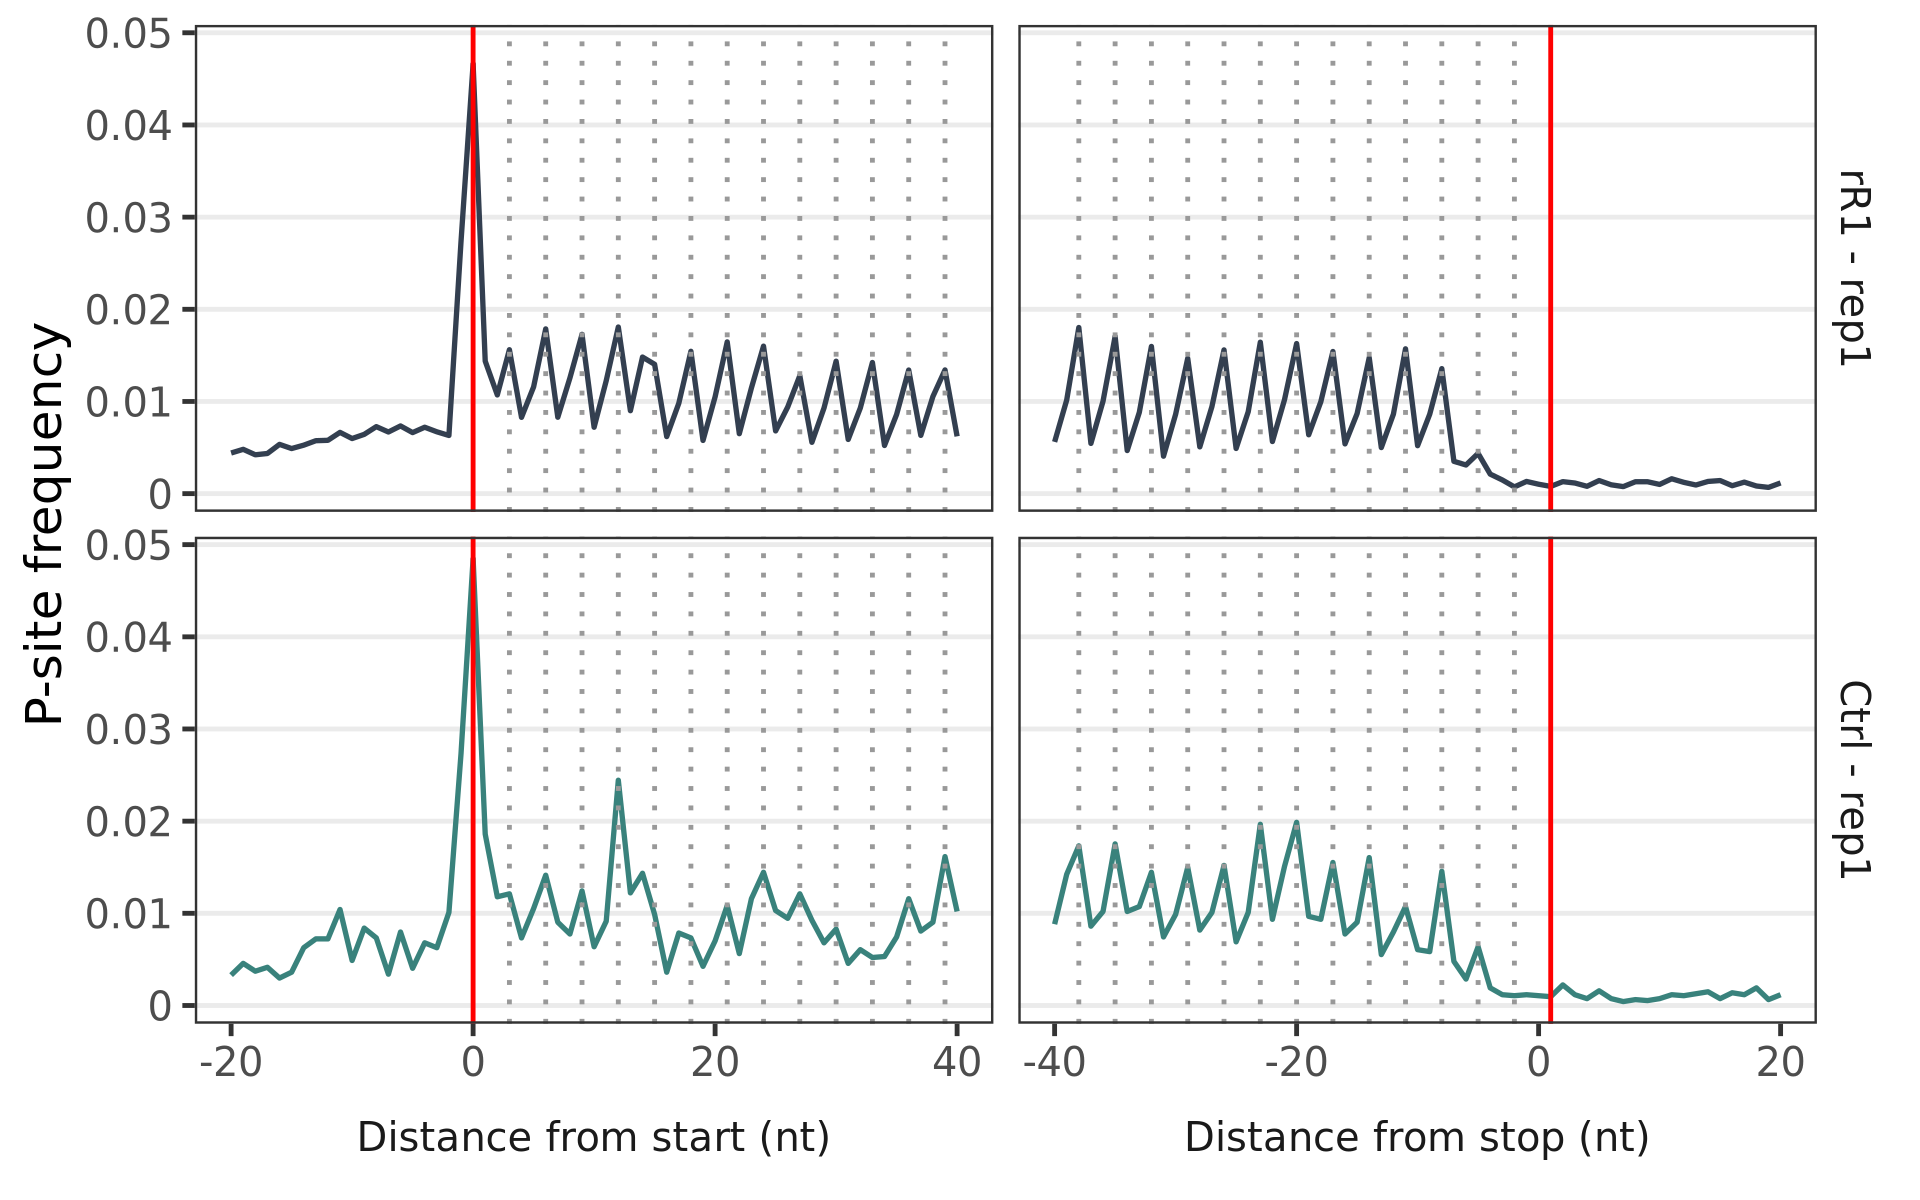

In [25]:
input_samples <- list("rR1 - rep1" = c("extract_B73_1_1"),
		      "Ctrl - rep1" = c("extract_B73_2_1"))

 example_metaprofile <- metaprofile_psite(reads_psite_list_th, cds,
                                          sample = input_samples,
                                          multisamples = "average",
                                          plot_style = "facet",
                                          utr5l = 20, cdsl = 40, utr3l = 20,
                                          colour = c("#333f50", "#39827c"))
 example_metaprofile[["plot"]]
ggsave("periodicity_rep1.pdf", width = 16, height = 10)

Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 244 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


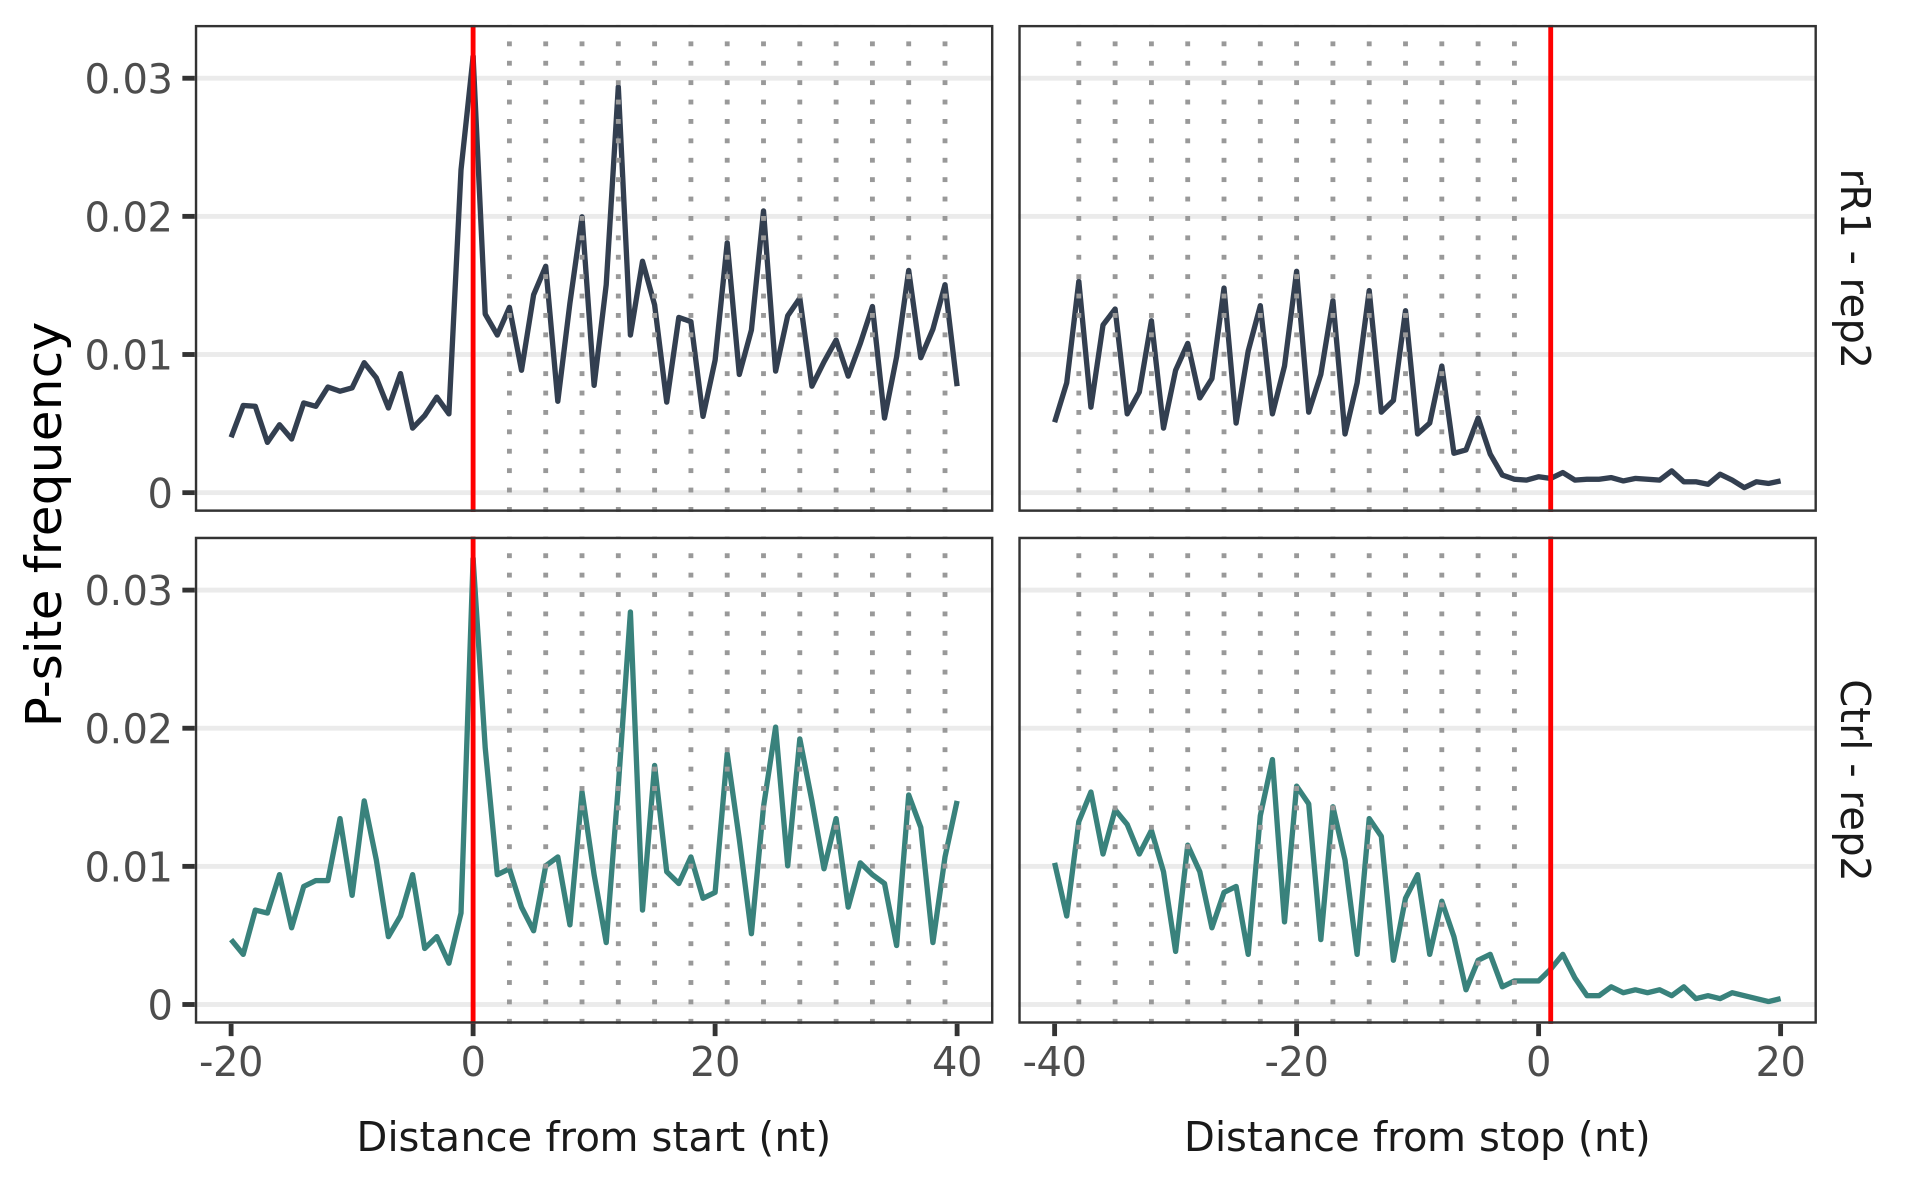

In [26]:
input_samples <- list("rR1 - rep2" = c("extract_B73_3_1"),
		      "Ctrl - rep2" = c("extract_B73_4_1"))

 example_metaprofile <- metaprofile_psite(reads_psite_list_th, cds,
                                          sample = input_samples,
                                          multisamples = "average",
                                          plot_style = "facet",
                                          utr5l = 20, cdsl = 40, utr3l = 20,
                                          colour = c("#333f50", "#39827c"))
 example_metaprofile[["plot"]]
ggsave("periodicity_rep2.pdf", width = 16, height = 10)

In [27]:
input_samples <- list("rR1 - rep1" = c("extract_B73_1_1"),
		      "Ctrl - rep1" = c("extract_B73_2_1"),
                     "rR1 - rep2" = c("extract_B73_3_1"),
		      "Ctrl - rep2" = c("extract_B73_4_1"))



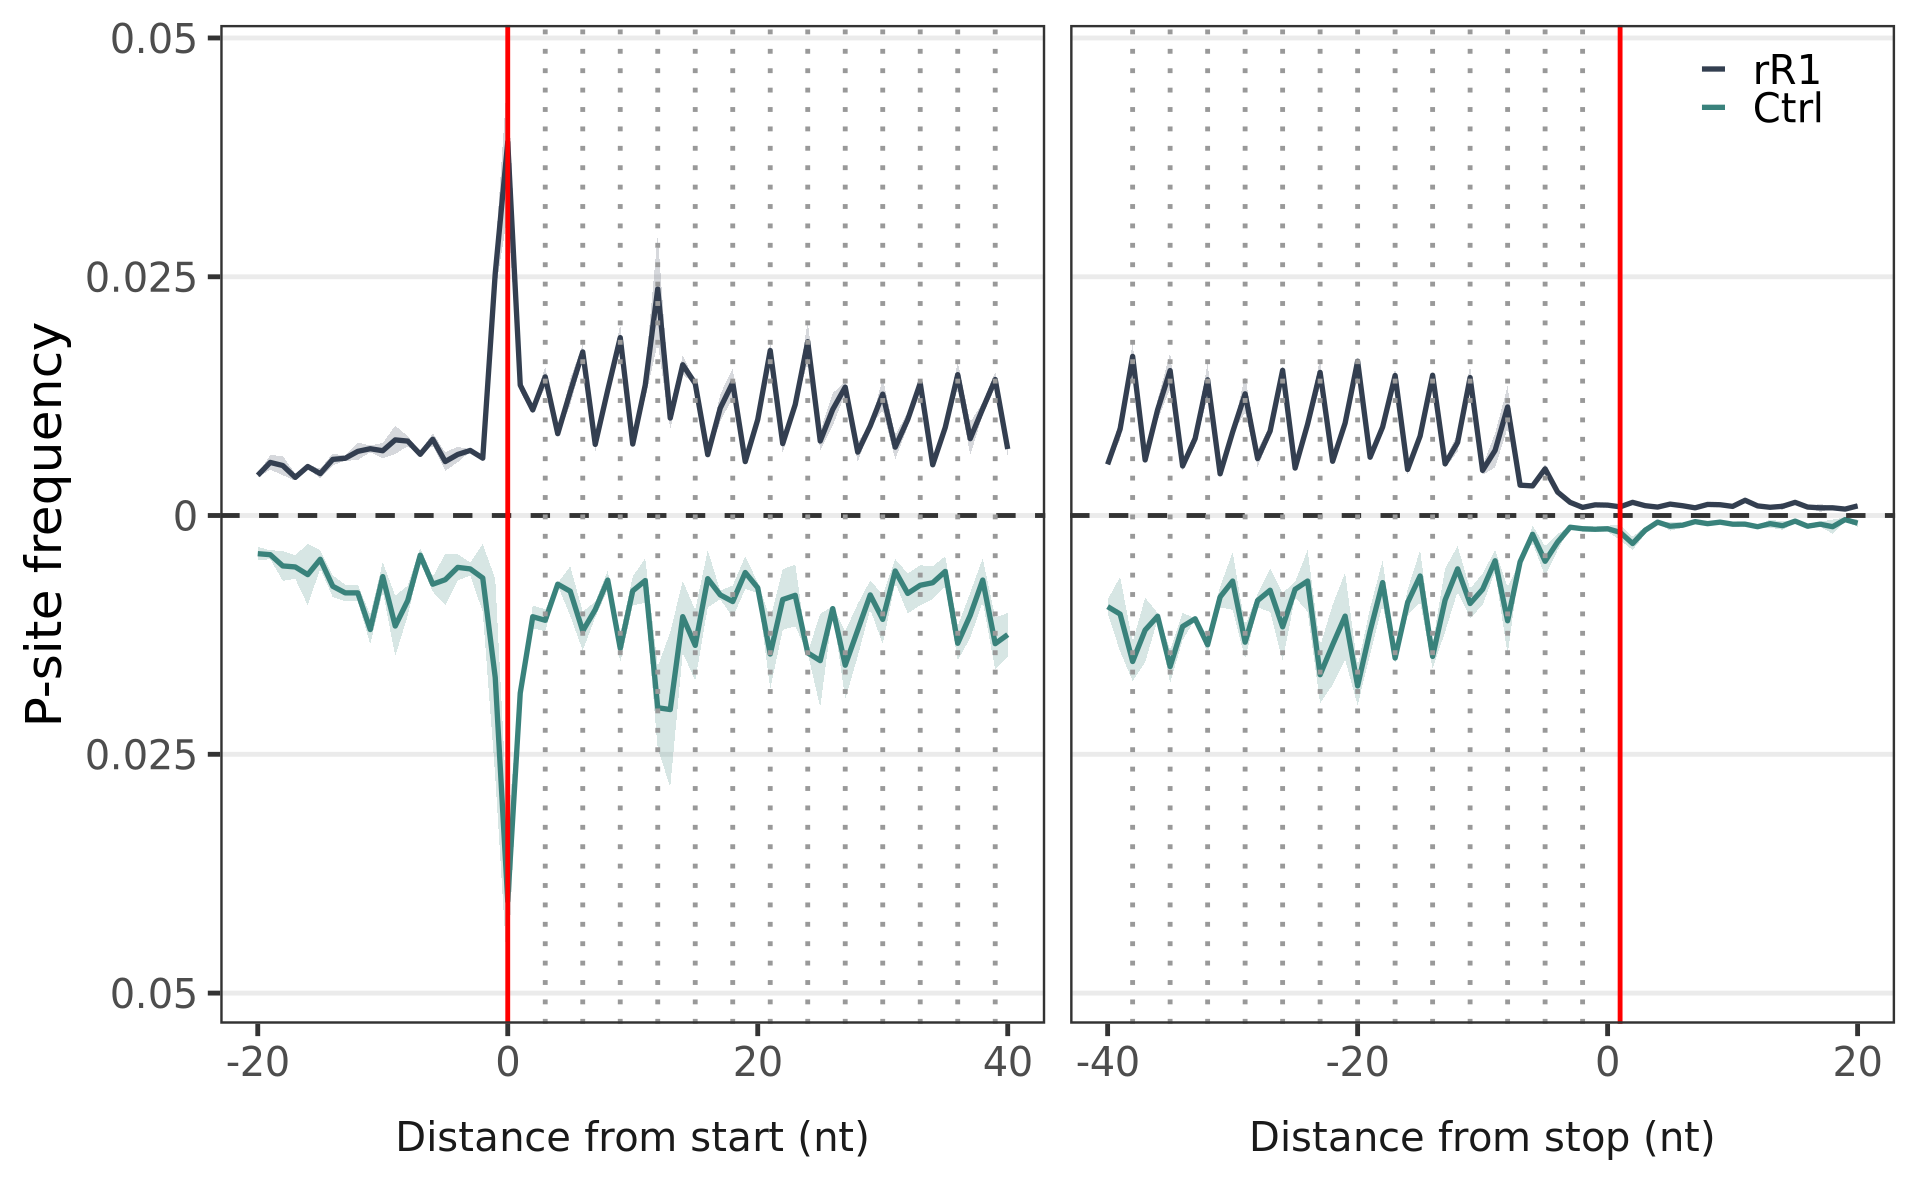

In [28]:
input_samples <- list("rR1" = c("extract_B73_1_1", "extract_B73_3_1"),
		      "Ctrl " = c("extract_B73_2_1", "extract_B73_4_1"))


example_metaprofile <- metaprofile_psite(reads_psite_list_th, cds,
                                         sample = input_samples,
                                         multisamples = "average",
                                         plot_style = "mirror",
                                         utr5l = 20, cdsl = 40, utr3l = 20,
                                         colour = c("#333f50", "#39827c"))



example_metaprofile[["plot"]]
ggsave("periodicity_average.pdf", width = 16, height = 10)

# length distribution

In [ ]:
input_samples <- list("rR1 - rep1" = c("extract_B73_1_1"),
		      "Ctrl - rep1" = c("extract_B73_2_1"),
                     "rR1 - rep2" = c("extract_B73_3_1"),
		      "Ctrl - rep2" = c("extract_B73_4_1"))


example_length_dist <- rlength_distr(filtered_list_manual,
  				       sample = input_samples,
  				       multisamples = "independent",
  				       plot_style = "mirror",
  				       cl = 99, colour = c("#333f50", "#39827c"))
  				  
example_length_dist[["plot"]]

In [ ]:
  example_length_dist <- rlength_distr(reads_psite_list,
  				       sample = input_samples,
  				       multisamples = "independent",
  				       plot_style = "mirror",
  				       cl = 99, colour = c("#333f50", "#39827c"))
  				  
  example_length_dist[["plot"]]

In [ ]:
example_length_dist <- rlength_distr(reads_list, sample = "extract_B73_1_1", 
				     colour = "#333f50")
example_length_dist[["plot_extract_B73_1_1"]]


In [ ]:
example_length_dist <- rlength_distr(reads_list, sample = "extract_B73_2_1", 
				     colour = "#333f50")
example_length_dist[["plot_extract_B73_2_1"]]


In [ ]:
example_length_dist <- rlength_distr(reads_list, sample = "extract_B73_4_1",
				     cl = 99, colour = "#333f50")
example_length_dist[["plot_extract_B73_4_1"]]

In [ ]:
example_length_dist <- rlength_distr(reads_list, sample = "extract_B73_4_1", 
				     colour = "#333f50")
example_length_dist[["plot_extract_B73_4_1"]]


In [ ]:
example_ends_heatmap <- rends_heat(reads_list, cds,
                                   sample = "extract_B73_4_1", cl = 85,
								   utr5l = 25, cdsl = 40, utr3l = 25,
								   colour = "#333f50")
example_ends_heatmap[["plot_Samp1"]]

# Codon usage plots 

In [66]:
input_samples <- list("rR1 - rep1" = c("extract_B73_1_1"),
		      "Ctrl - rep1" = c("extract_B73_2_1"),
                     "rR1 - rep2" = c("extract_B73_3_1"),
		      "Ctrl - rep2" = c("extract_B73_4_1"))


In [300]:
cds_coverage_example <- cds_coverage(reads_psite_list_th, cds)

processing extract_B73_1_1
processing extract_B73_2_1
processing extract_B73_3_1
processing extract_B73_4_1


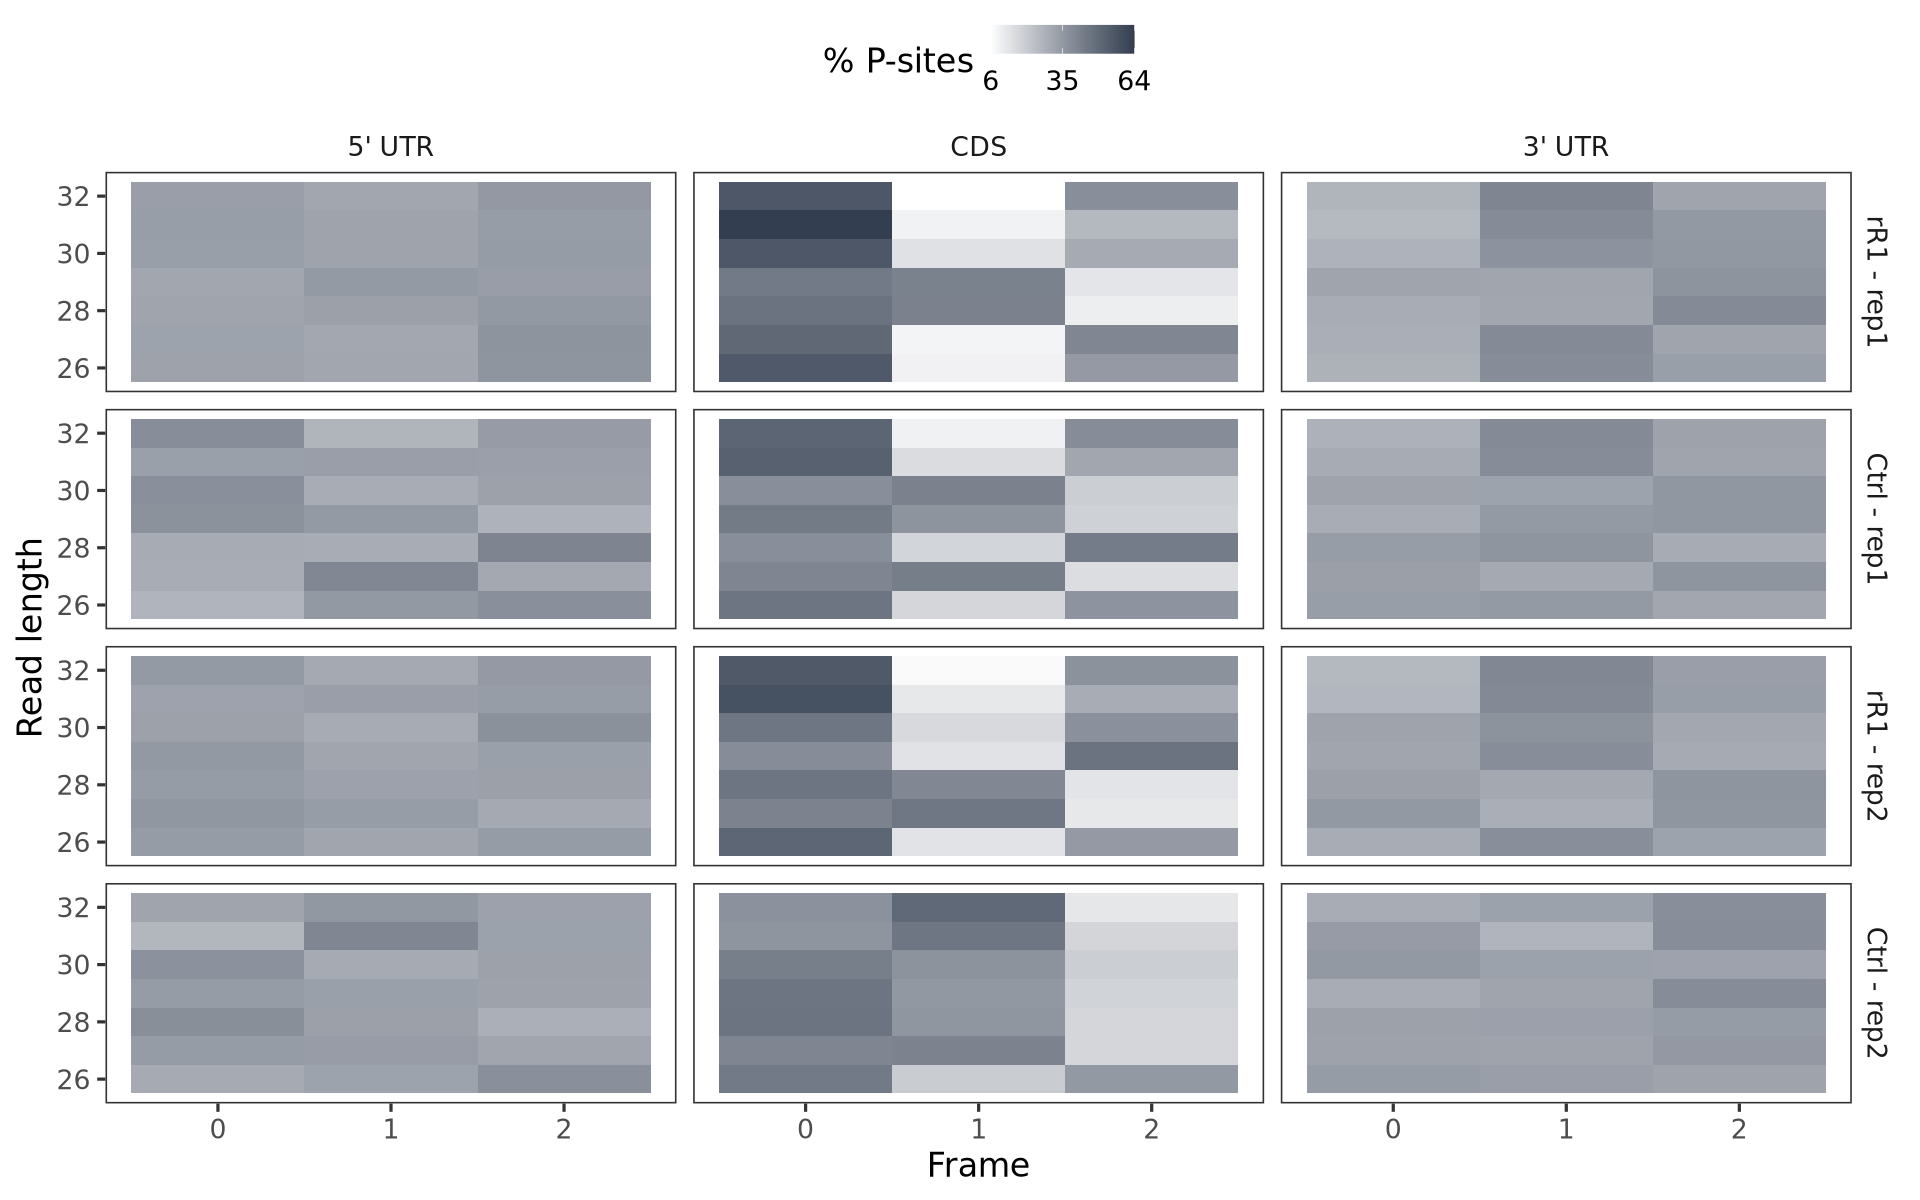

In [72]:

 			  
 example_frames_stratified <- frame_psite_length(reads_psite_list_th, cds,
                                                 sample = input_samples,
                                                 multisamples = "average",
                                                 plot_style = "facet",
                                                 region = "all",
                                                 cl = 85, colour = "#333f50")
 example_frames_stratified[["plot"]]
ggsave("frame_all_samples.svg", width = 12, height = 10)

In [177]:
reads_psite_list_th2 <- lapply(
  reads_psite_list_th,
  function(dt) dt[length >= 27 & length <= 33]
)
cds_coverage_example <- cds_coverage(reads_psite_list_th2, cds)

processing extract_B73_1_1
processing extract_B73_2_1
processing extract_B73_3_1
processing extract_B73_4_1


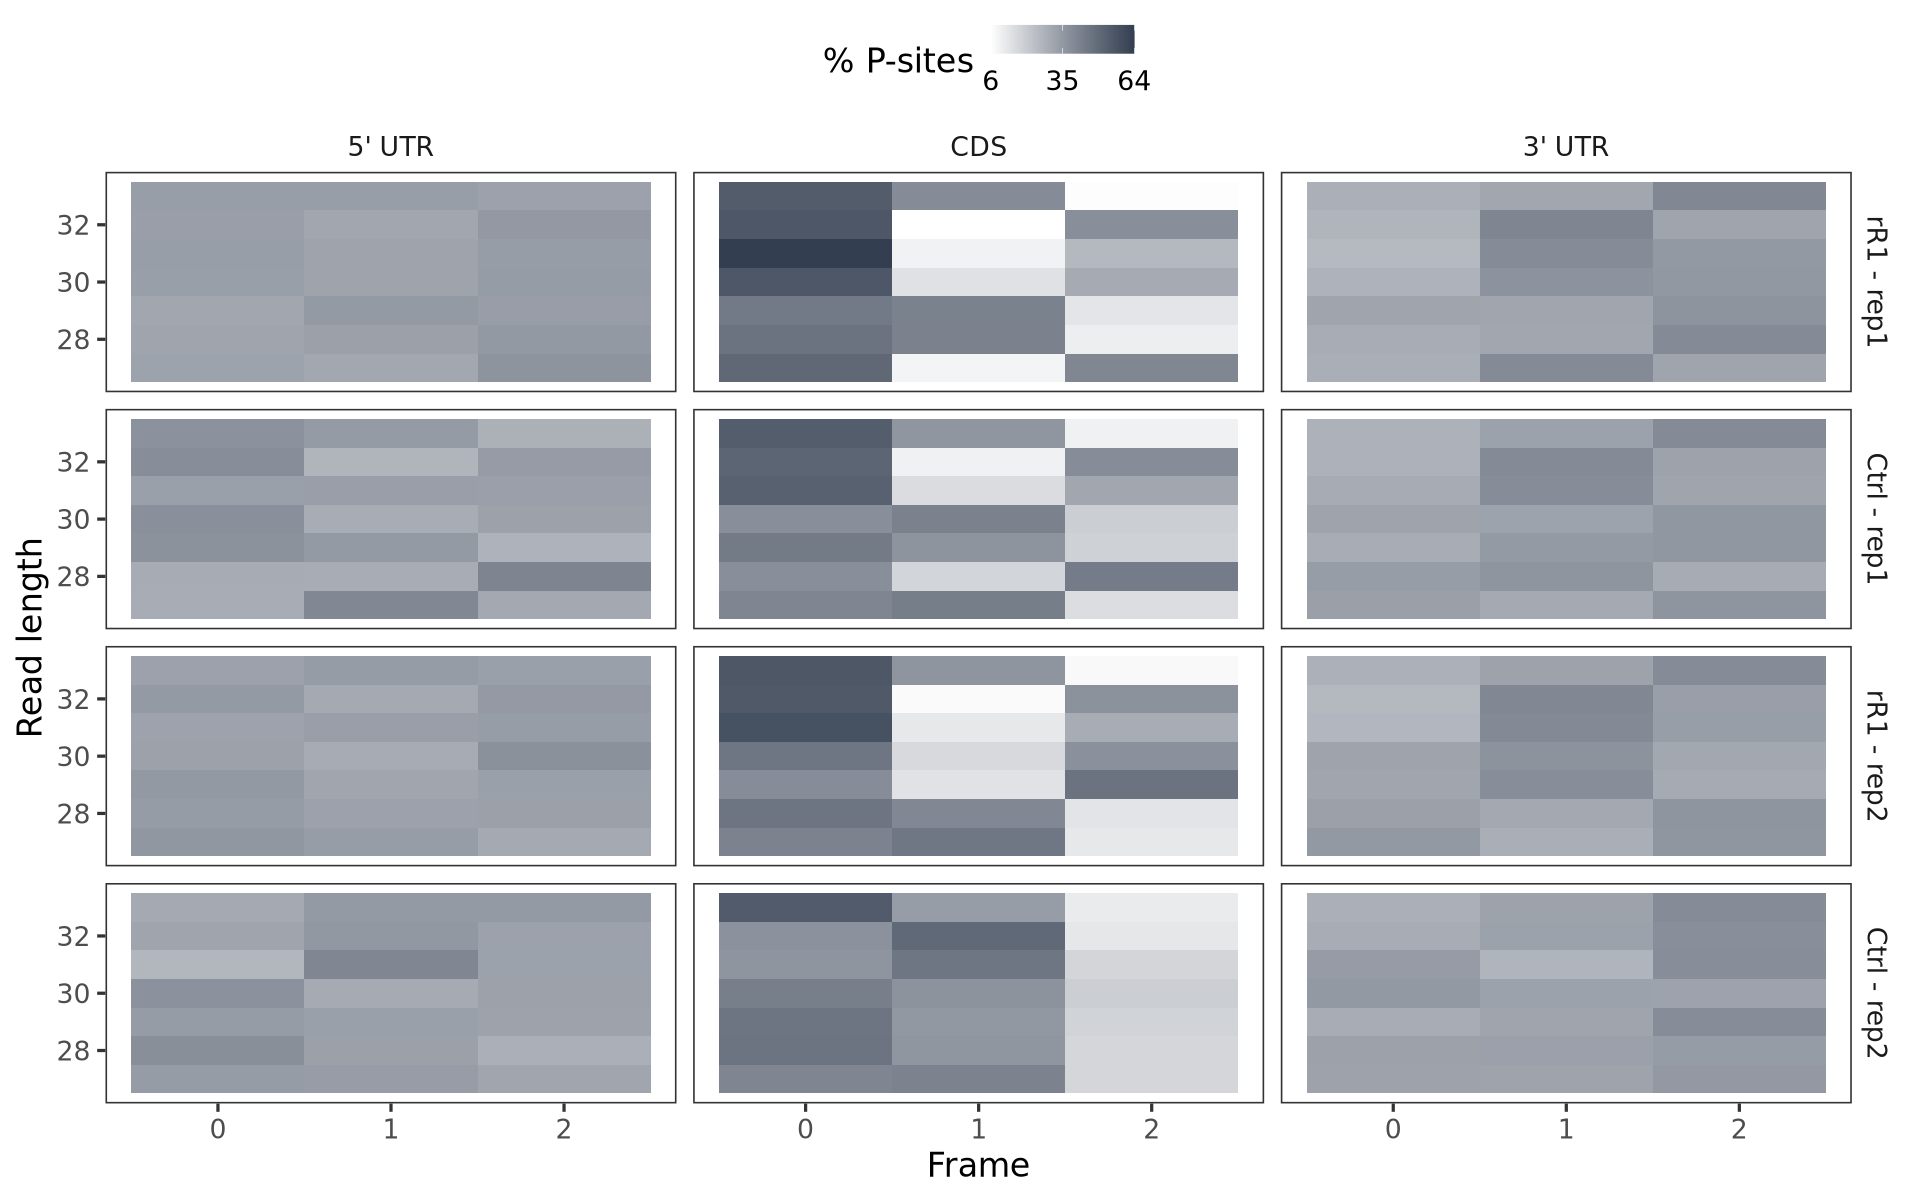

In [178]:

 			  
 example_frames_stratified <- frame_psite_length(reads_psite_list_th2, cds,
                                                 sample = input_samples,
                                                 multisamples = "average",
                                                 plot_style = "facet",
                                                 region = "all",
                                                 cl = 85, colour = "#333f50")
 example_frames_stratified[["plot"]]

In [197]:
reads_psite_list_th2 <- lapply(
  reads_psite_list_th,
  function(dt) dt[length >= 24 & length <= 42]
)
cds_coverage_example <- cds_coverage(reads_psite_list_th2, cds)

processing extract_B73_1_1
processing extract_B73_2_1
processing extract_B73_3_1
processing extract_B73_4_1


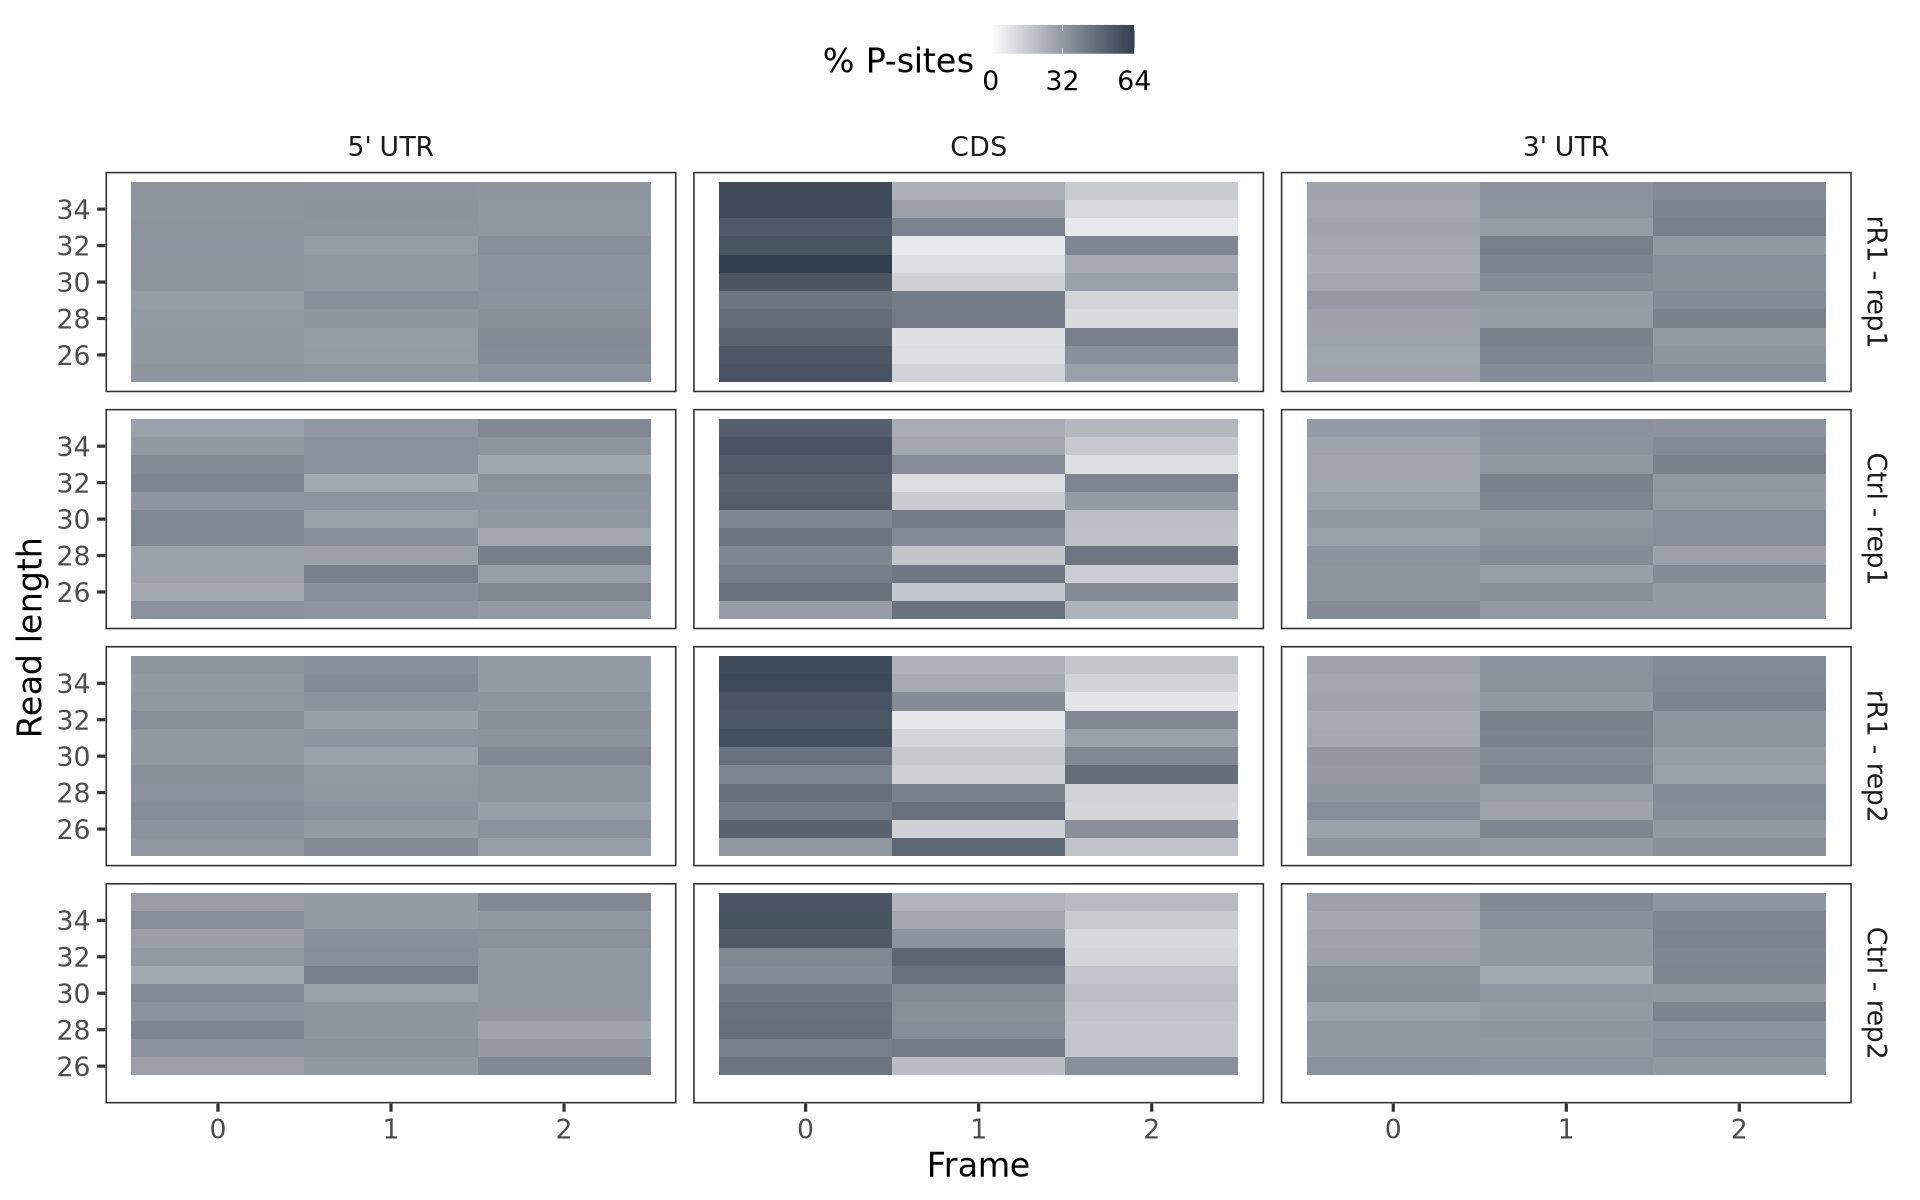

In [186]:

 			  
 example_frames_stratified <- frame_psite_length(reads_psite_list_th2, cds,
                                                 sample = input_samples,
                                                 multisamples = "average",
                                                 plot_style = "facet",
                                                 region = "all",
                                                 cl = 85, colour = "#333f50")
 example_frames_stratified[["plot"]]

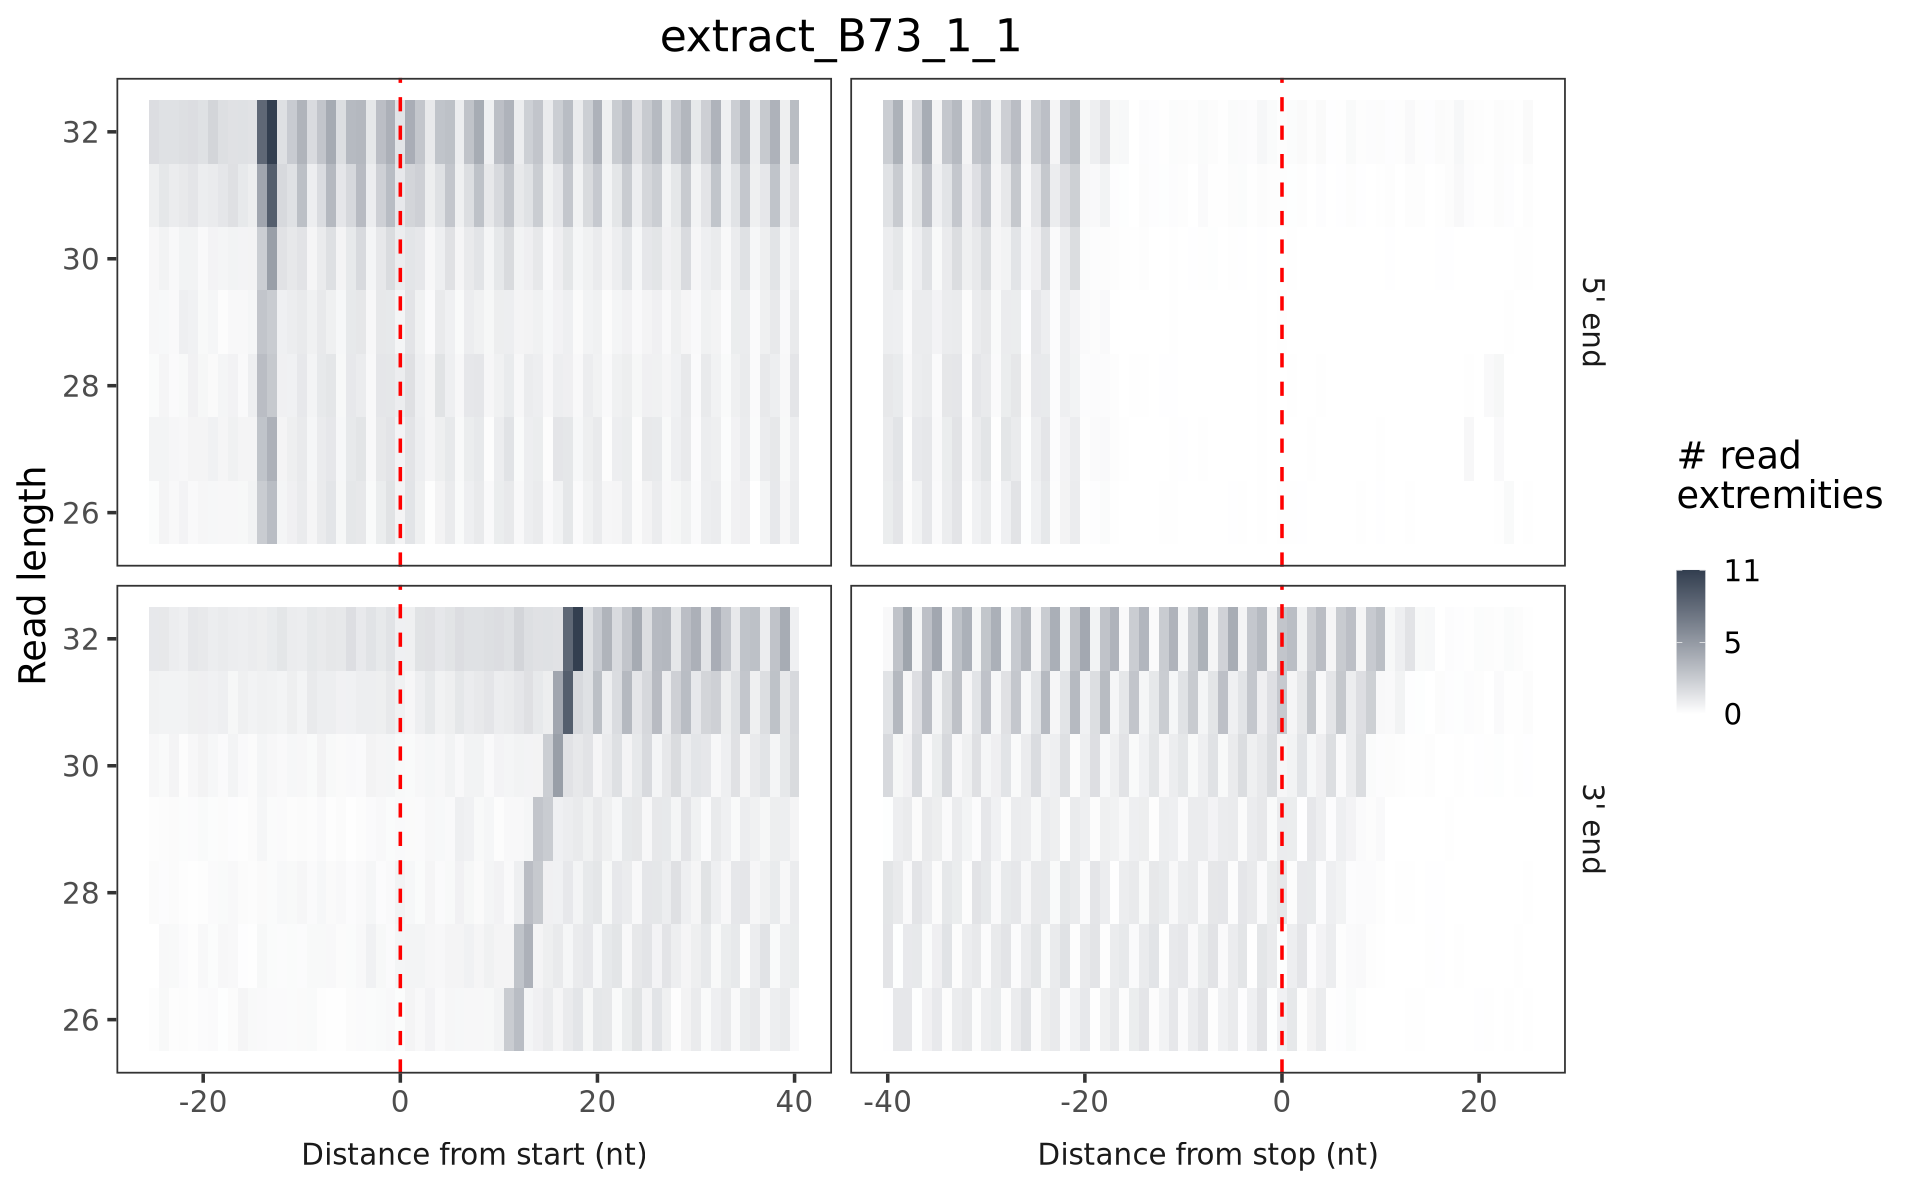

In [294]:
reads_psite_list_th2 <- lapply(
  reads_psite_list_th,
  function(dt) dt[length >= 24 & length <= 42]
)
example_ends_heatmap <- rends_heat(reads_psite_list_th, cds,
                                   sample = "extract_B73_1_1", cl = 85,
								   utr5l = 25, cdsl = 40, utr3l = 25,
								   colour = "#333f50")
example_ends_heatmap[["plot_extract_B73_1_1"]]

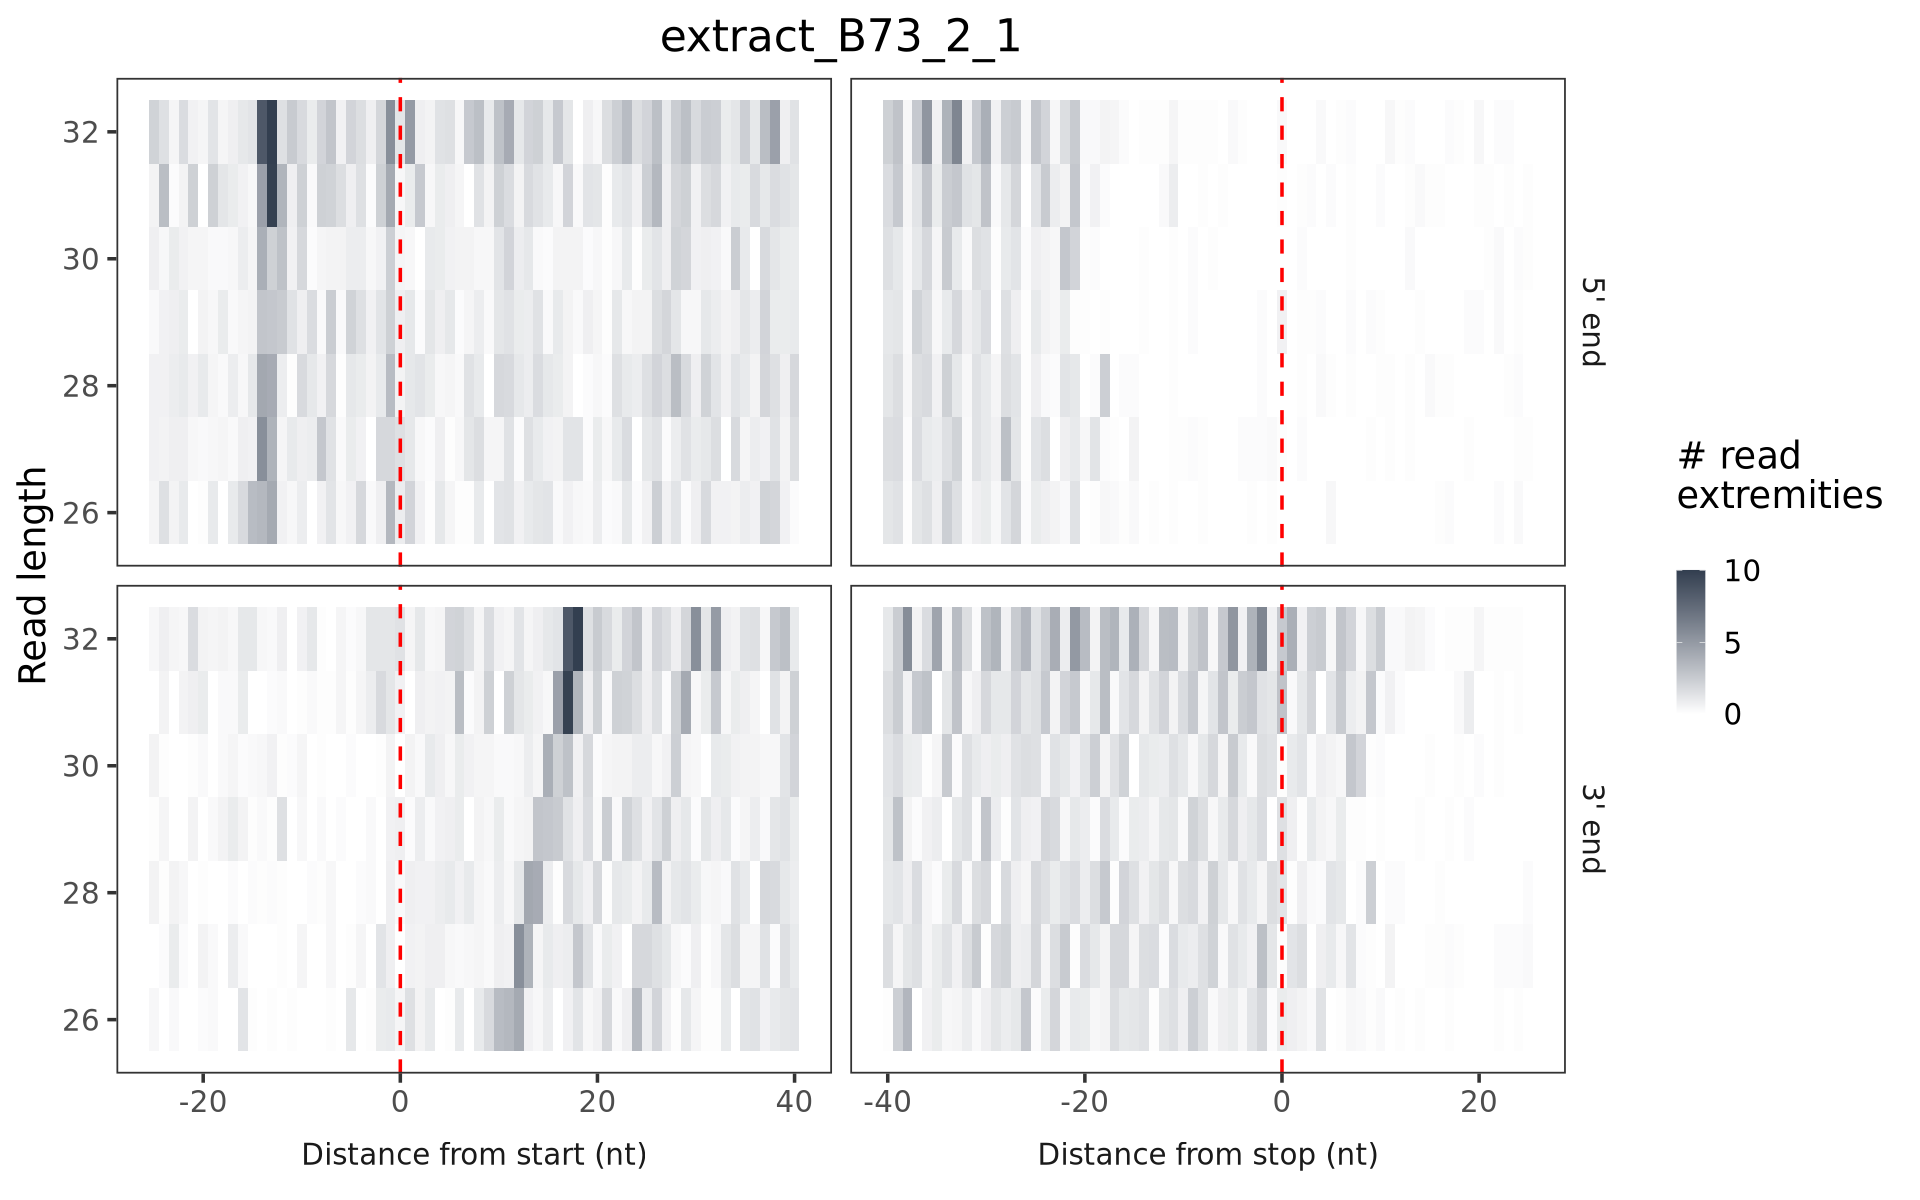

In [295]:


example_ends_heatmap <- rends_heat(reads_psite_list_th, cds,
                                   sample = "extract_B73_2_1", cl = 85,
								   utr5l = 25, cdsl = 40, utr3l = 25,
								   colour = "#333f50")
example_ends_heatmap[["plot_extract_B73_2_1"]]

In [213]:
#reads_psite_list_th

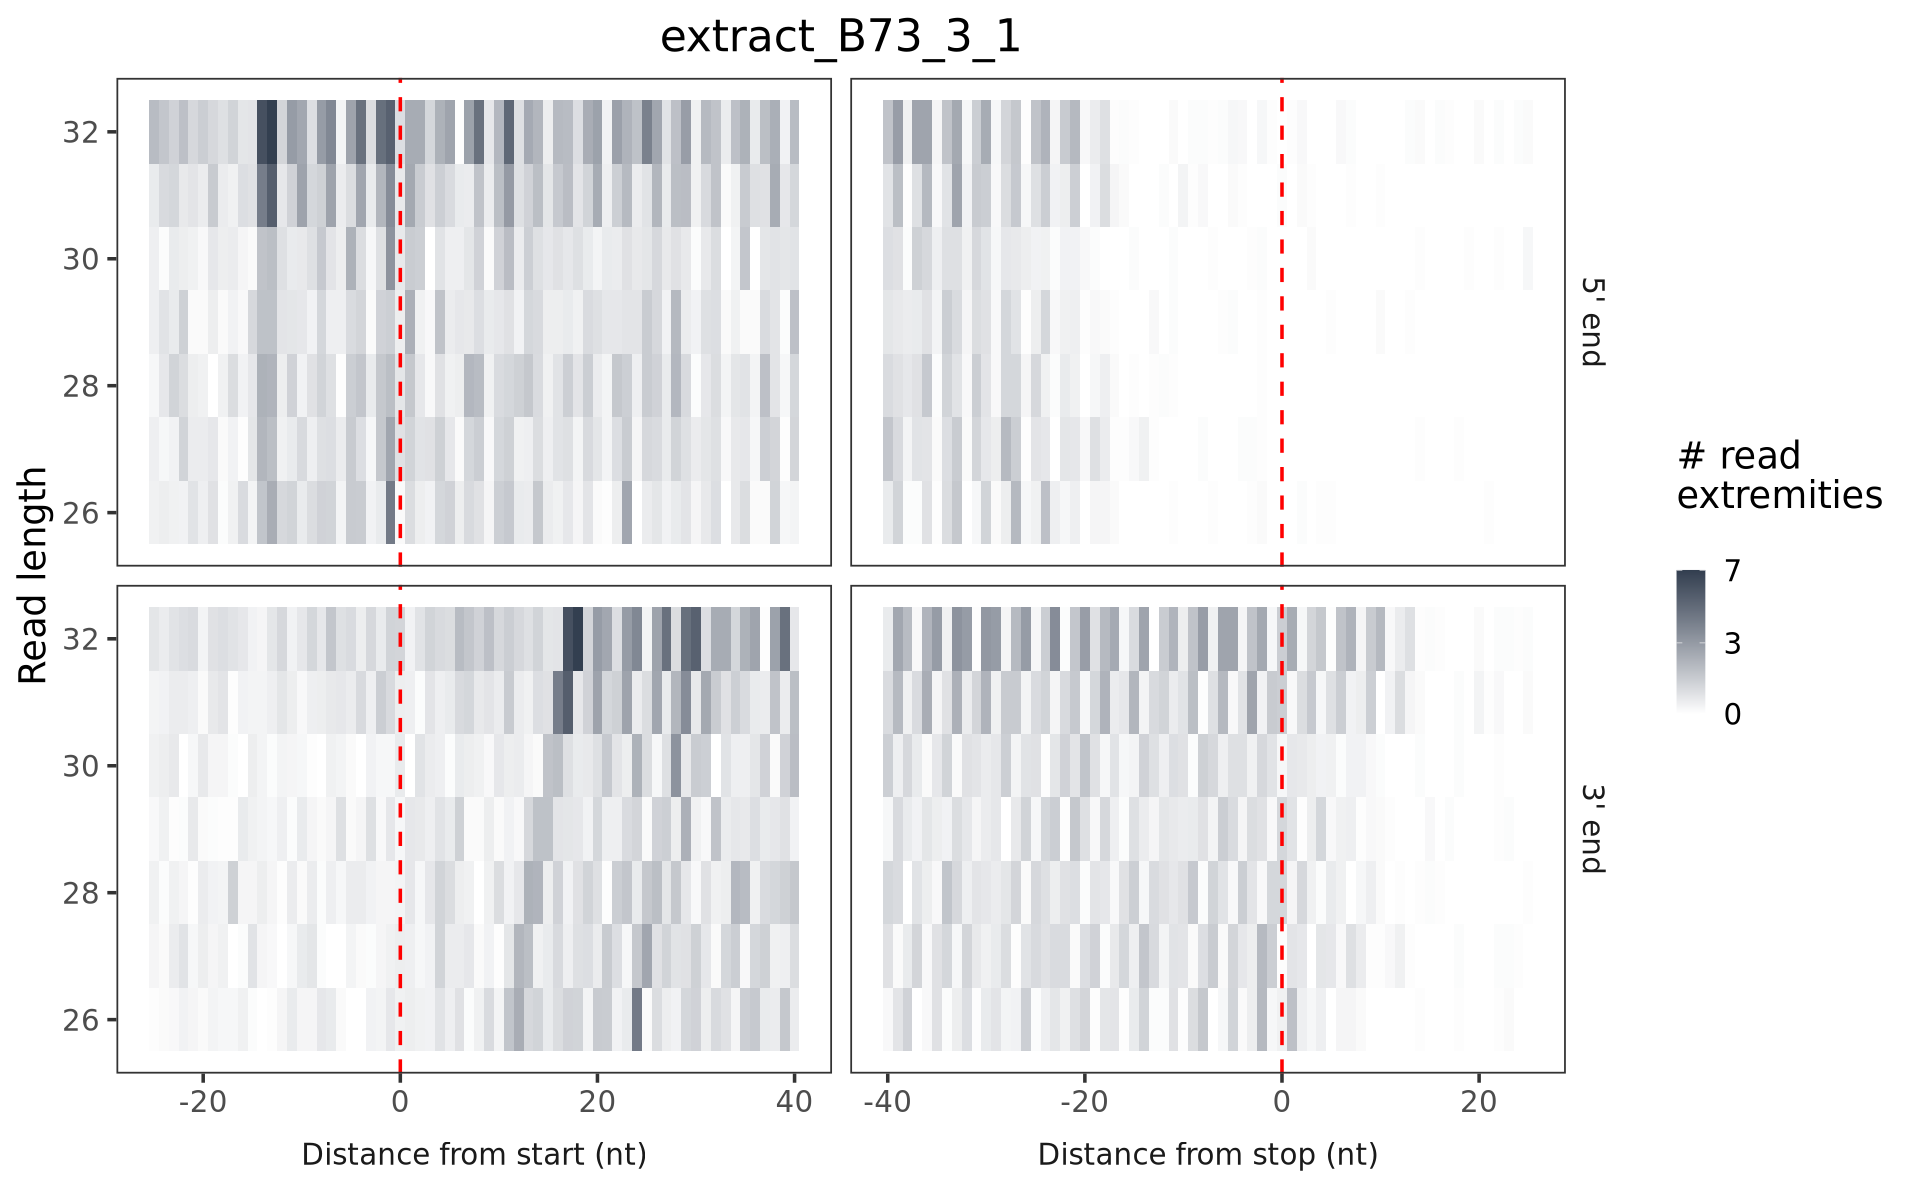

In [296]:


example_ends_heatmap <- rends_heat(reads_psite_list_th, cds,
                                   sample = "extract_B73_3_1", cl = 85,
								   utr5l = 25, cdsl = 40, utr3l = 25,
								   colour = "#333f50")
example_ends_heatmap[["plot_extract_B73_3_1"]]

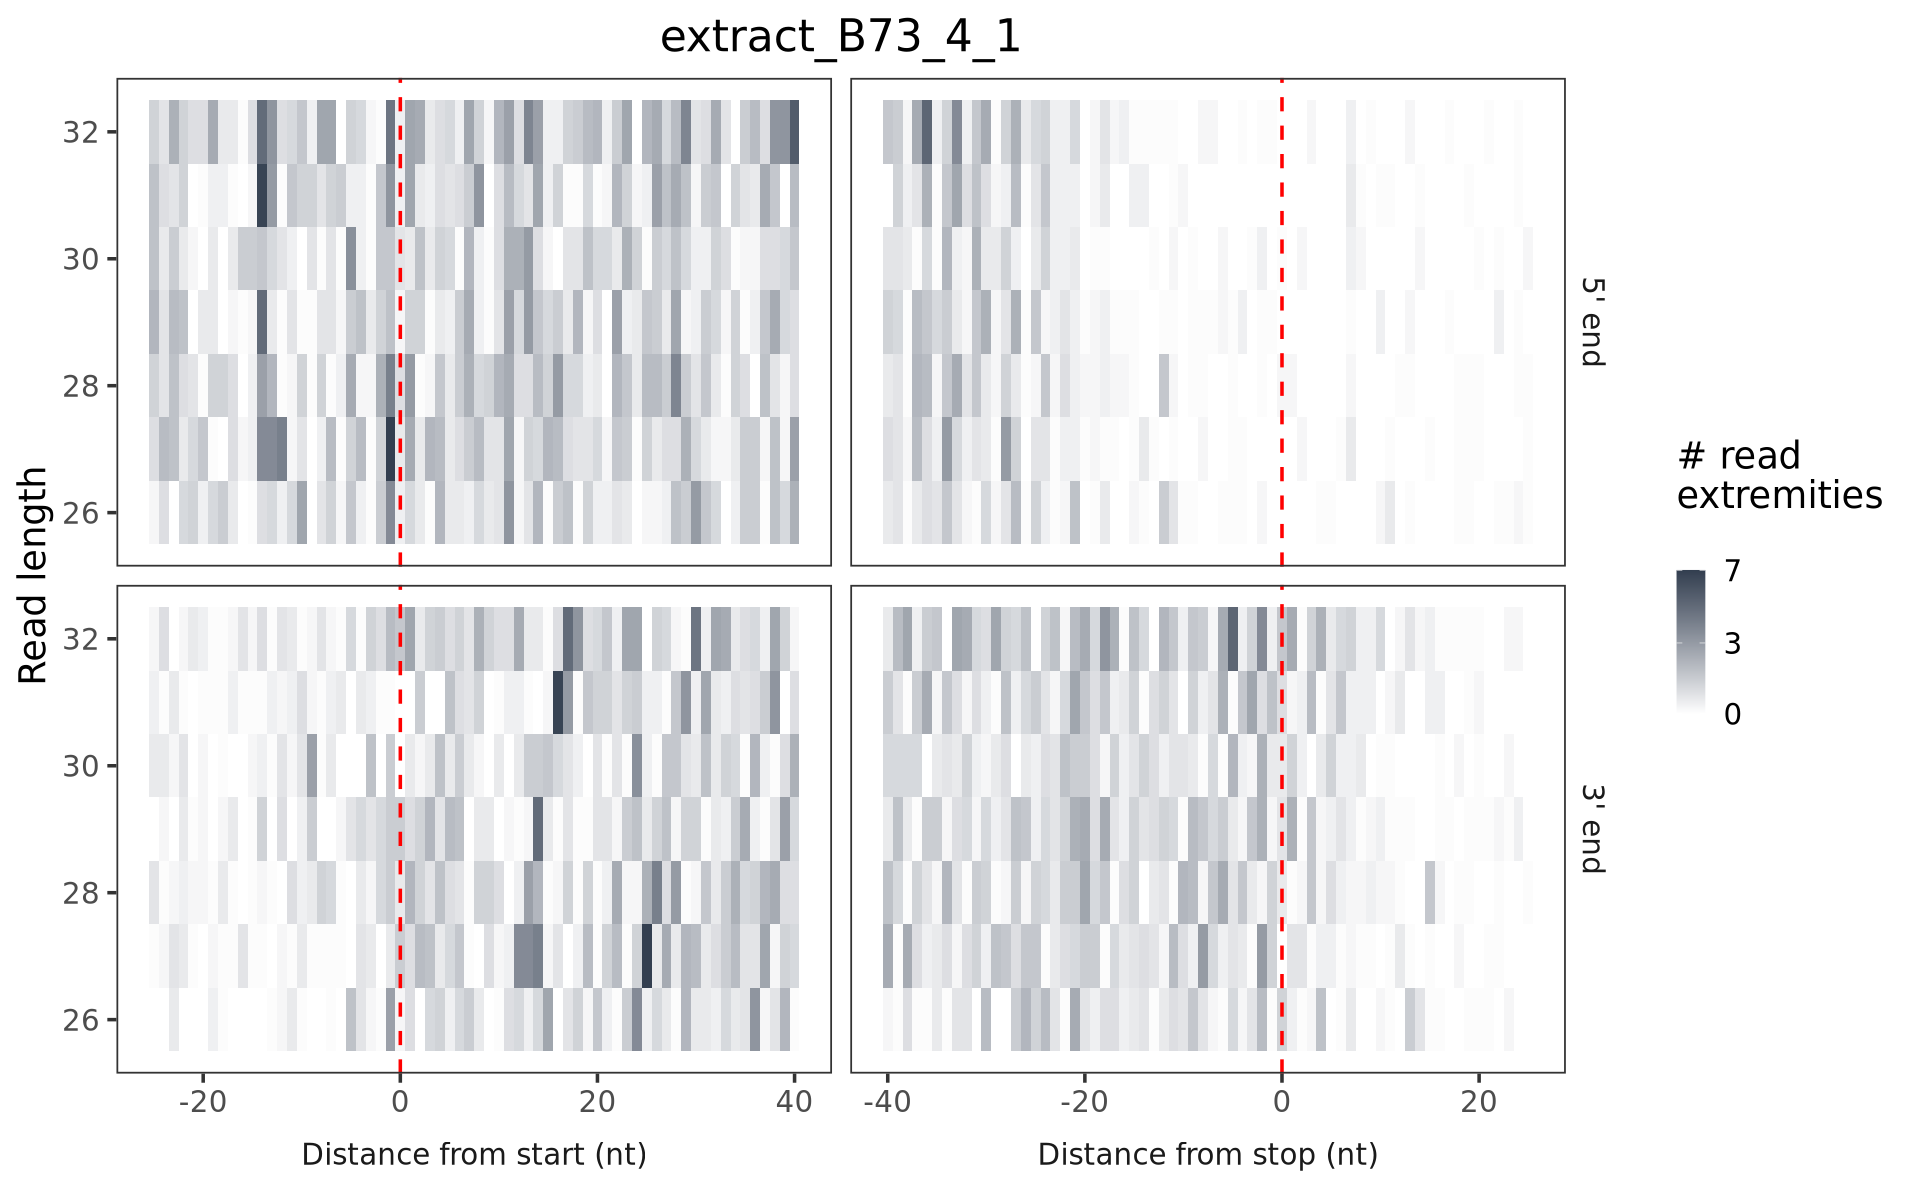

In [297]:
example_ends_heatmap <- rends_heat(reads_psite_list_th, cds,
                                   sample = "extract_B73_4_1", cl = 85,
								   utr5l = 25, cdsl = 40, utr3l = 25,
								   colour = "#333f50")
example_ends_heatmap[["plot_extract_B73_4_1"]]

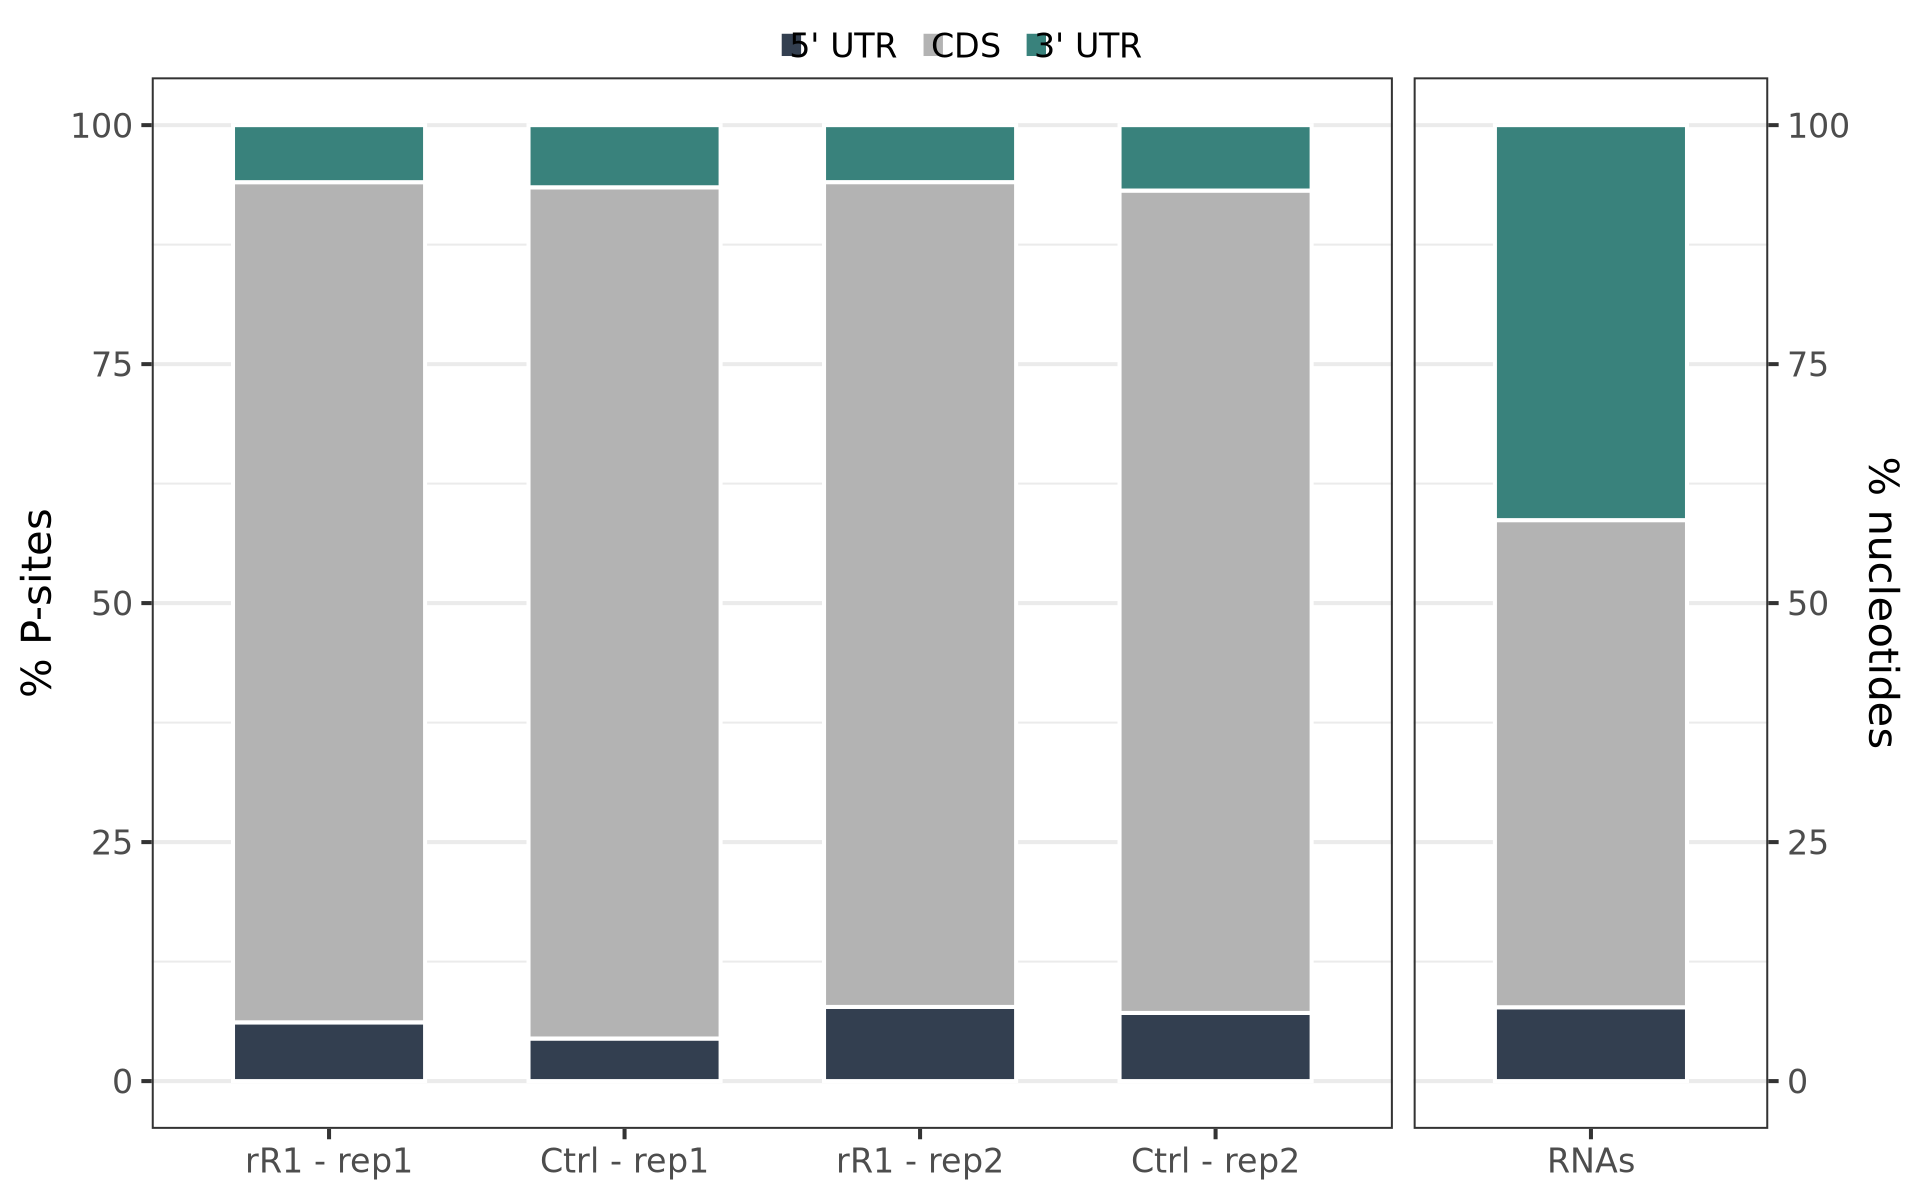

In [73]:
example_psite_per_region <- region_psite(reads_psite_list_th, cds,
					 sample = input_samples,
					 multisamples = "average",
					 plot_style = "stack",
					 cl = 85,
					 colour = c("#333f50", "gray70", "#39827c"))
example_psite_per_region[["plot"]]
ggsave("psite_composition.svg", width = 12, height = 10)

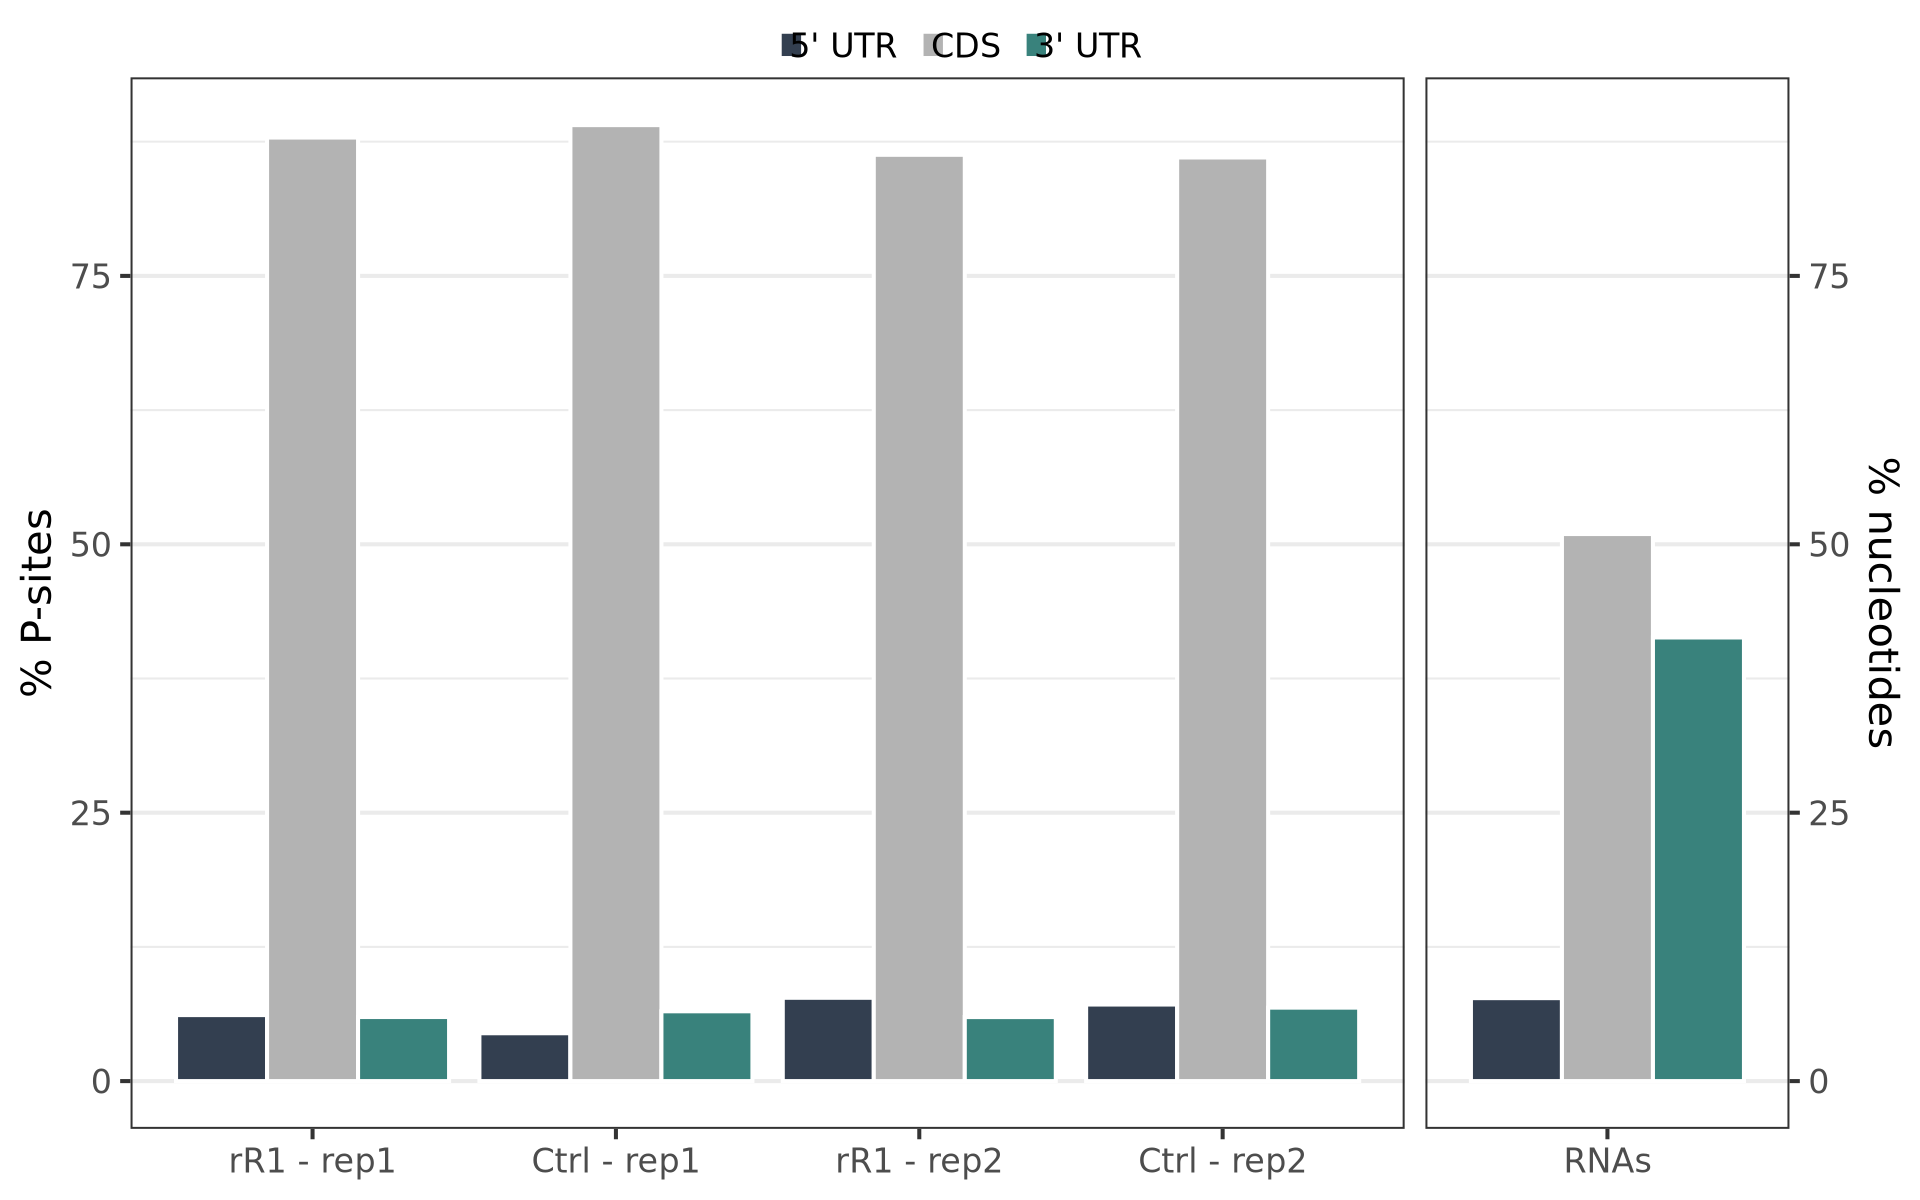

In [303]:
example_psite_per_region <- region_psite(reads_psite_list_th, cds,
					 sample = input_samples,
					 multisamples = "average",
					 plot_style = "dodge",
					 cl = 85,
					 colour = c("#333f50", "gray70", "#39827c"))
example_psite_per_region[["plot"]]

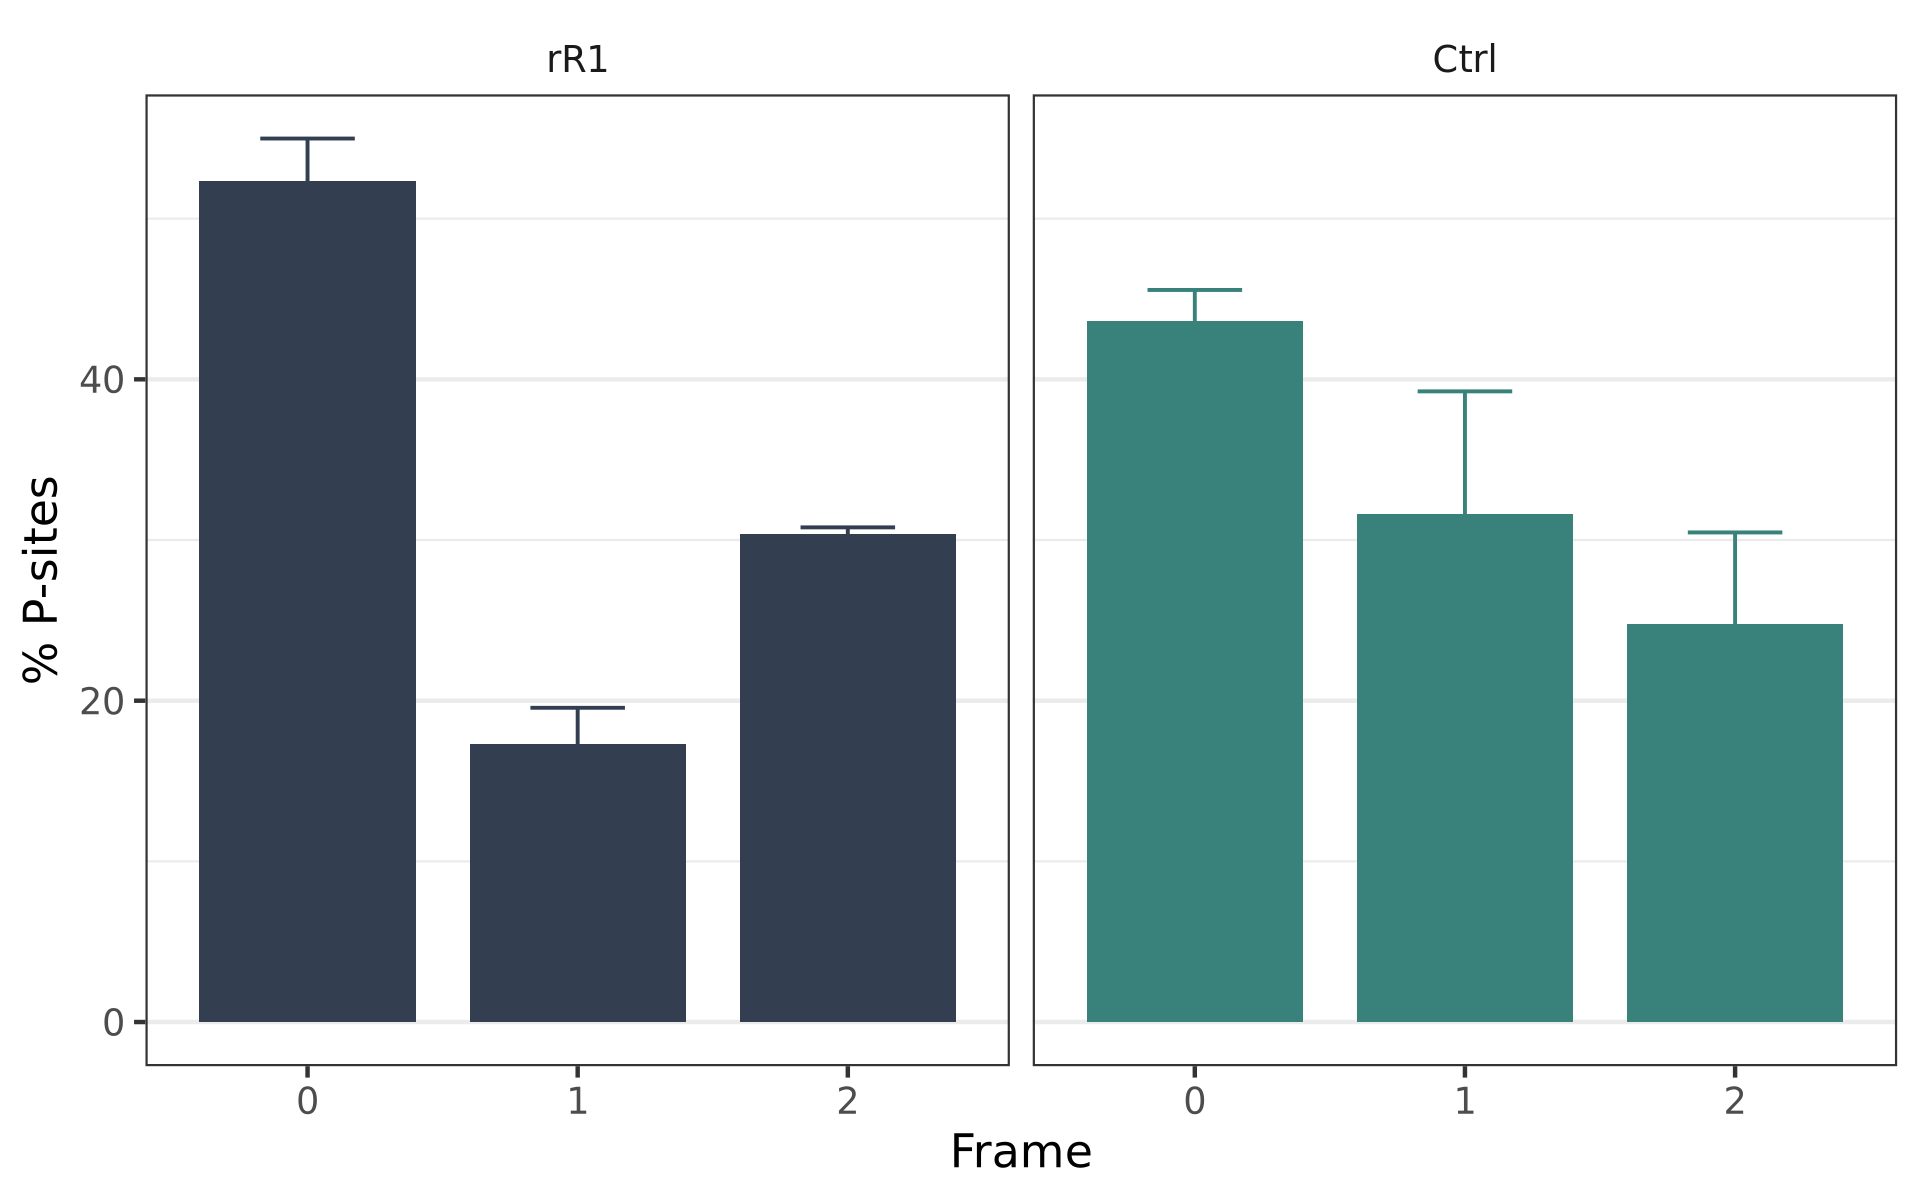

In [30]:
input_samples <- list("rR1" = c("extract_B73_1_1", "extract_B73_3_1"),
		      "Ctrl" = c("extract_B73_2_1", "extract_B73_4_1"))

example_frames <- frame_psite(reads_psite_list_th, cds,
                               sample = input_samples,
                               multisamples = "average",
                               plot_style = "facet",
                               region = "cds",
                               colour = c("#333f50", "#39827c"))
 example_frames[["plot"]]

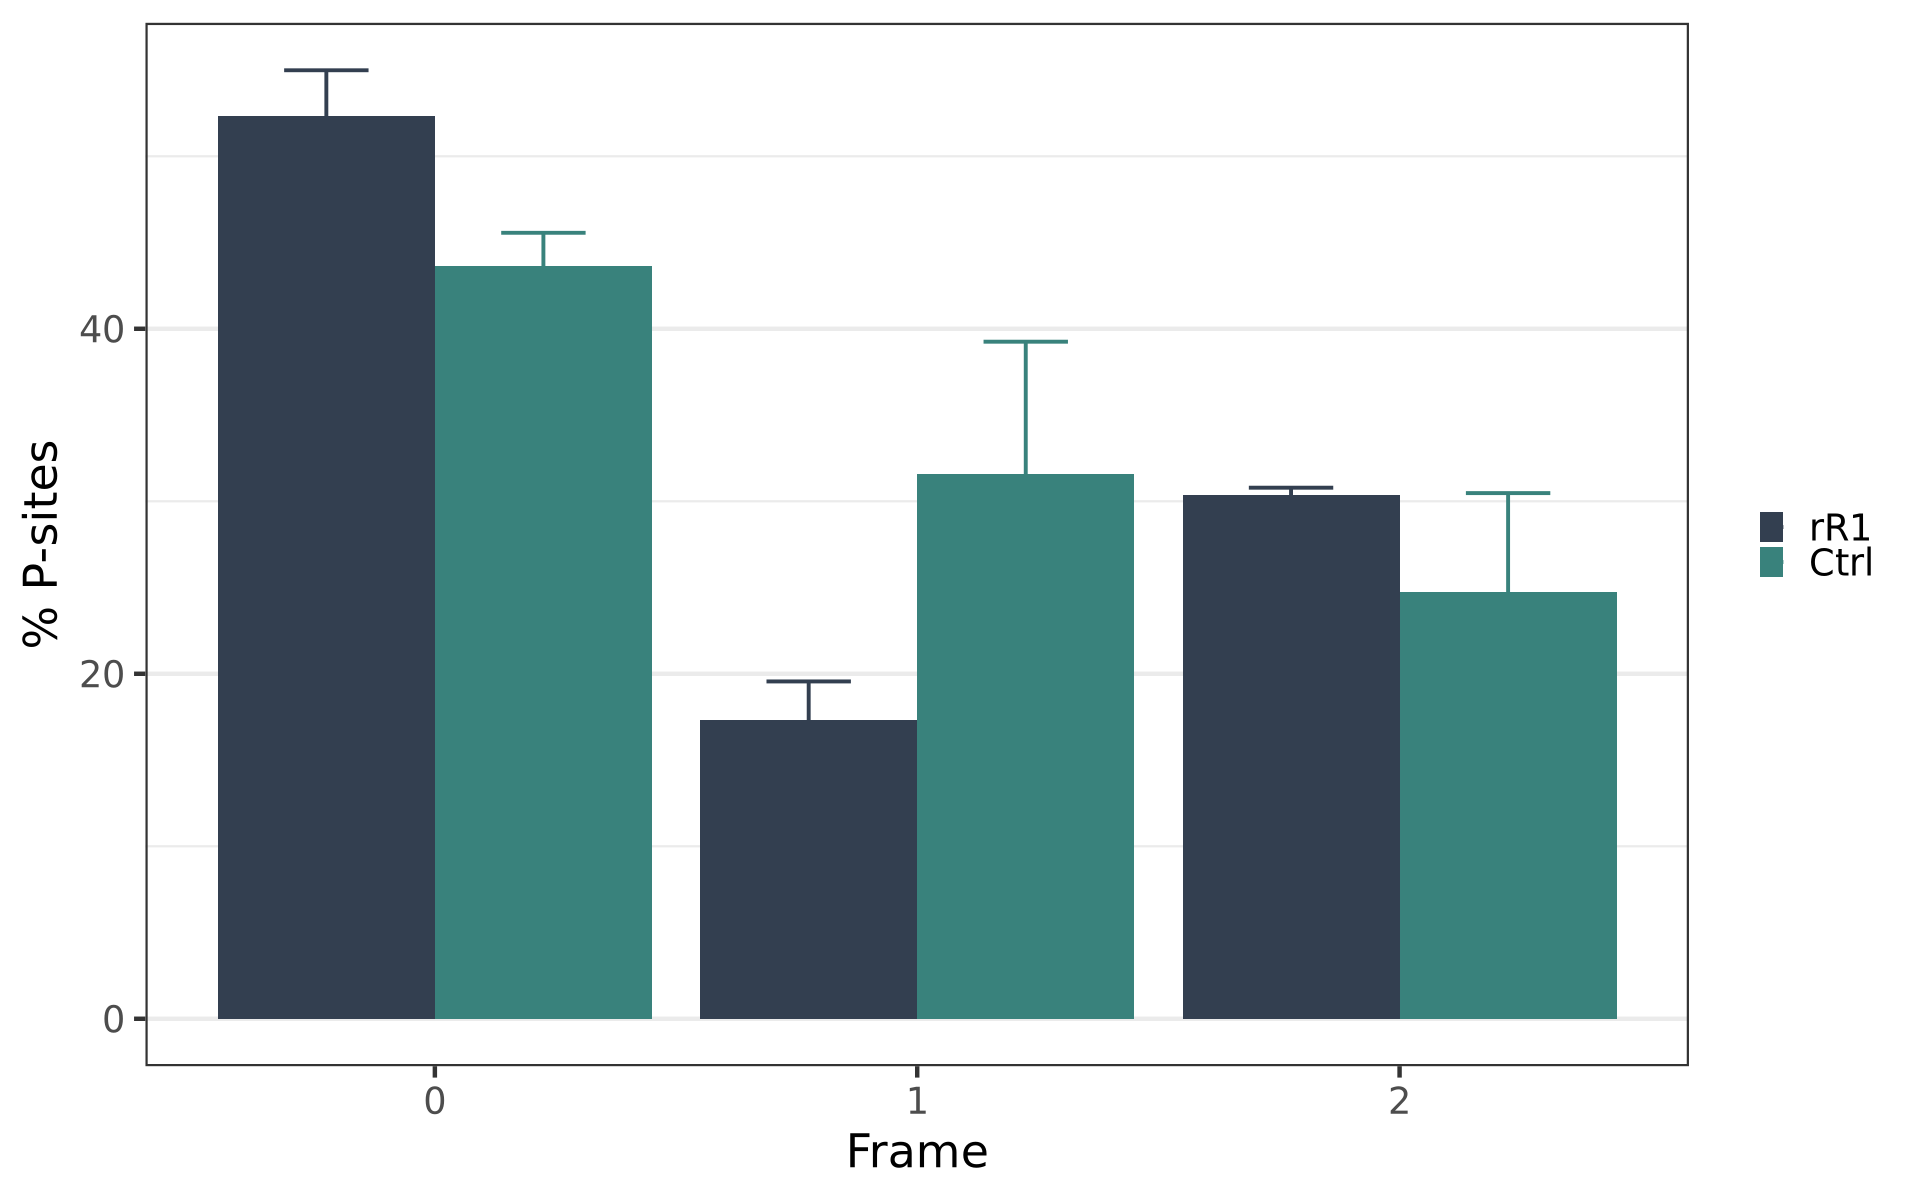

In [32]:
input_samples <- list("rR1" = c("extract_B73_1_1", "extract_B73_3_1"),
		      "Ctrl" = c("extract_B73_2_1", "extract_B73_4_1"))

example_frames <- frame_psite(reads_psite_list_th, cds,
                               sample = input_samples,
                               multisamples = "average",
                               plot_style = "dodge",
                               region = "cds",
                               colour = c("#333f50", "#39827c"))
 example_frames[["plot"]]

In [46]:
library(dplyr)
library(purrr)

psite_long <- imap_dfr(
  reads_psite_list_th,
  ~ .x %>%
      mutate(sample_name = .y)
)

In [47]:
psite_long <- psite_long %>%
  filter(psite_region == "cds") %>%
  mutate(frame = psite_from_start %% 3)



	Wilcoxon rank sum test with continuity correction

data:  frame0_frac by condition
W = 595275, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


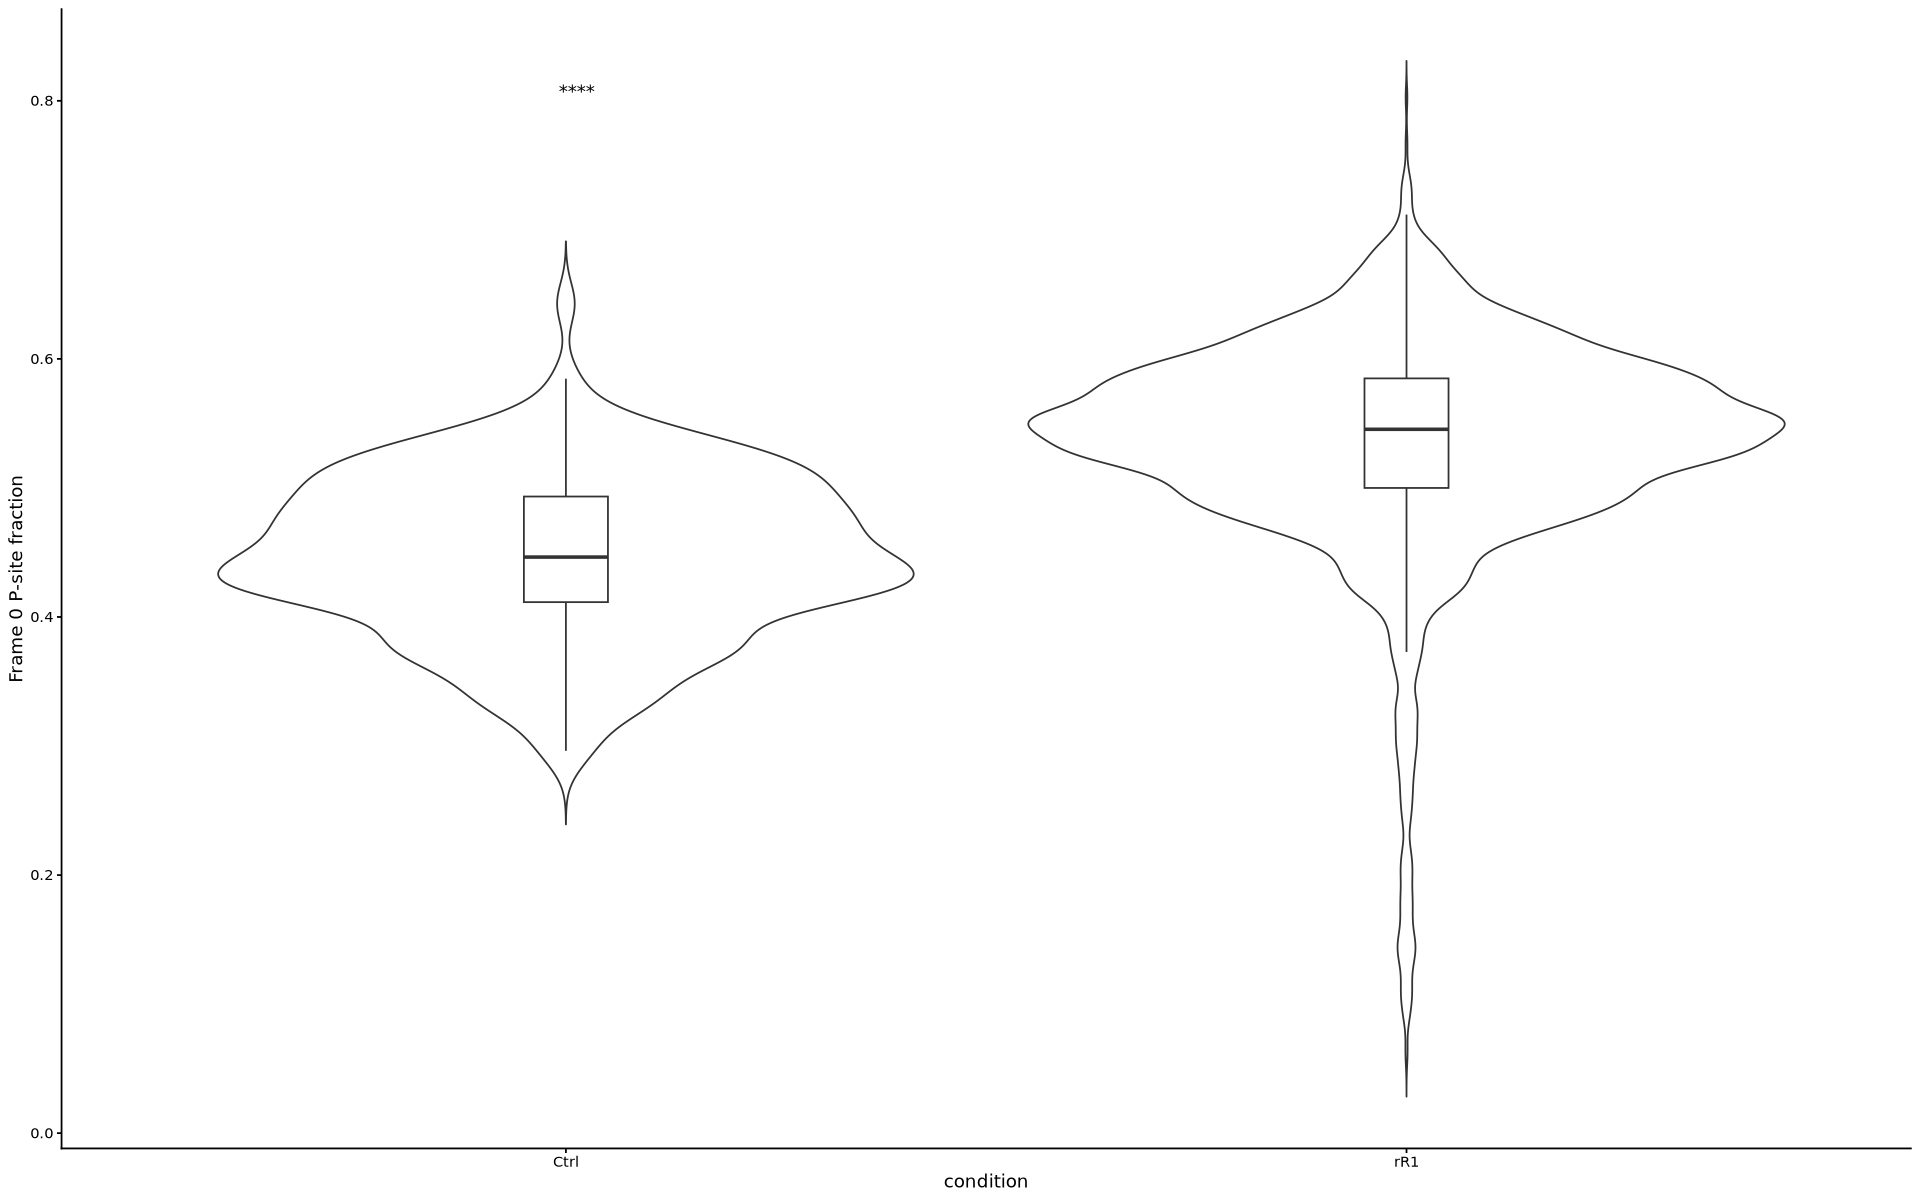

In [54]:
# computer the frame-0 fraction per transcript (per sample)
library(dplyr)

frame_tx <- psite_long %>%
  filter(psite_region == "cds") %>%   # critical
  group_by(sample_name, transcript) %>%
  summarise(
    total_psites = n(),
    frame0_frac = mean(frame == 0),
    .groups = "drop"
  )

#Important filtering (do not skip)
#Low-coverage transcripts will add noise:
frame_tx <- frame_tx %>% filter(total_psites >= 50)

frame_tx <- frame_tx %>%
  mutate(condition = case_when(
    sample_name %in% c("extract_B73_1_1", "extract_B73_3_1") ~ "rR1",
    sample_name %in% c("extract_B73_2_1", "extract_B73_4_1") ~ "Ctrl"
  ))

wilcox.test(frame0_frac ~ condition, data = frame_tx)


library(ggplot2)
library(ggpubr)

ggplot(frame_tx, aes(condition, frame0_frac)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.1, outlier.shape = NA) +
  stat_compare_means(
    method = "wilcox.test",
    label = "p.signif"
  ) +
  ylab("Frame 0 P-site fraction") +
  theme_classic()



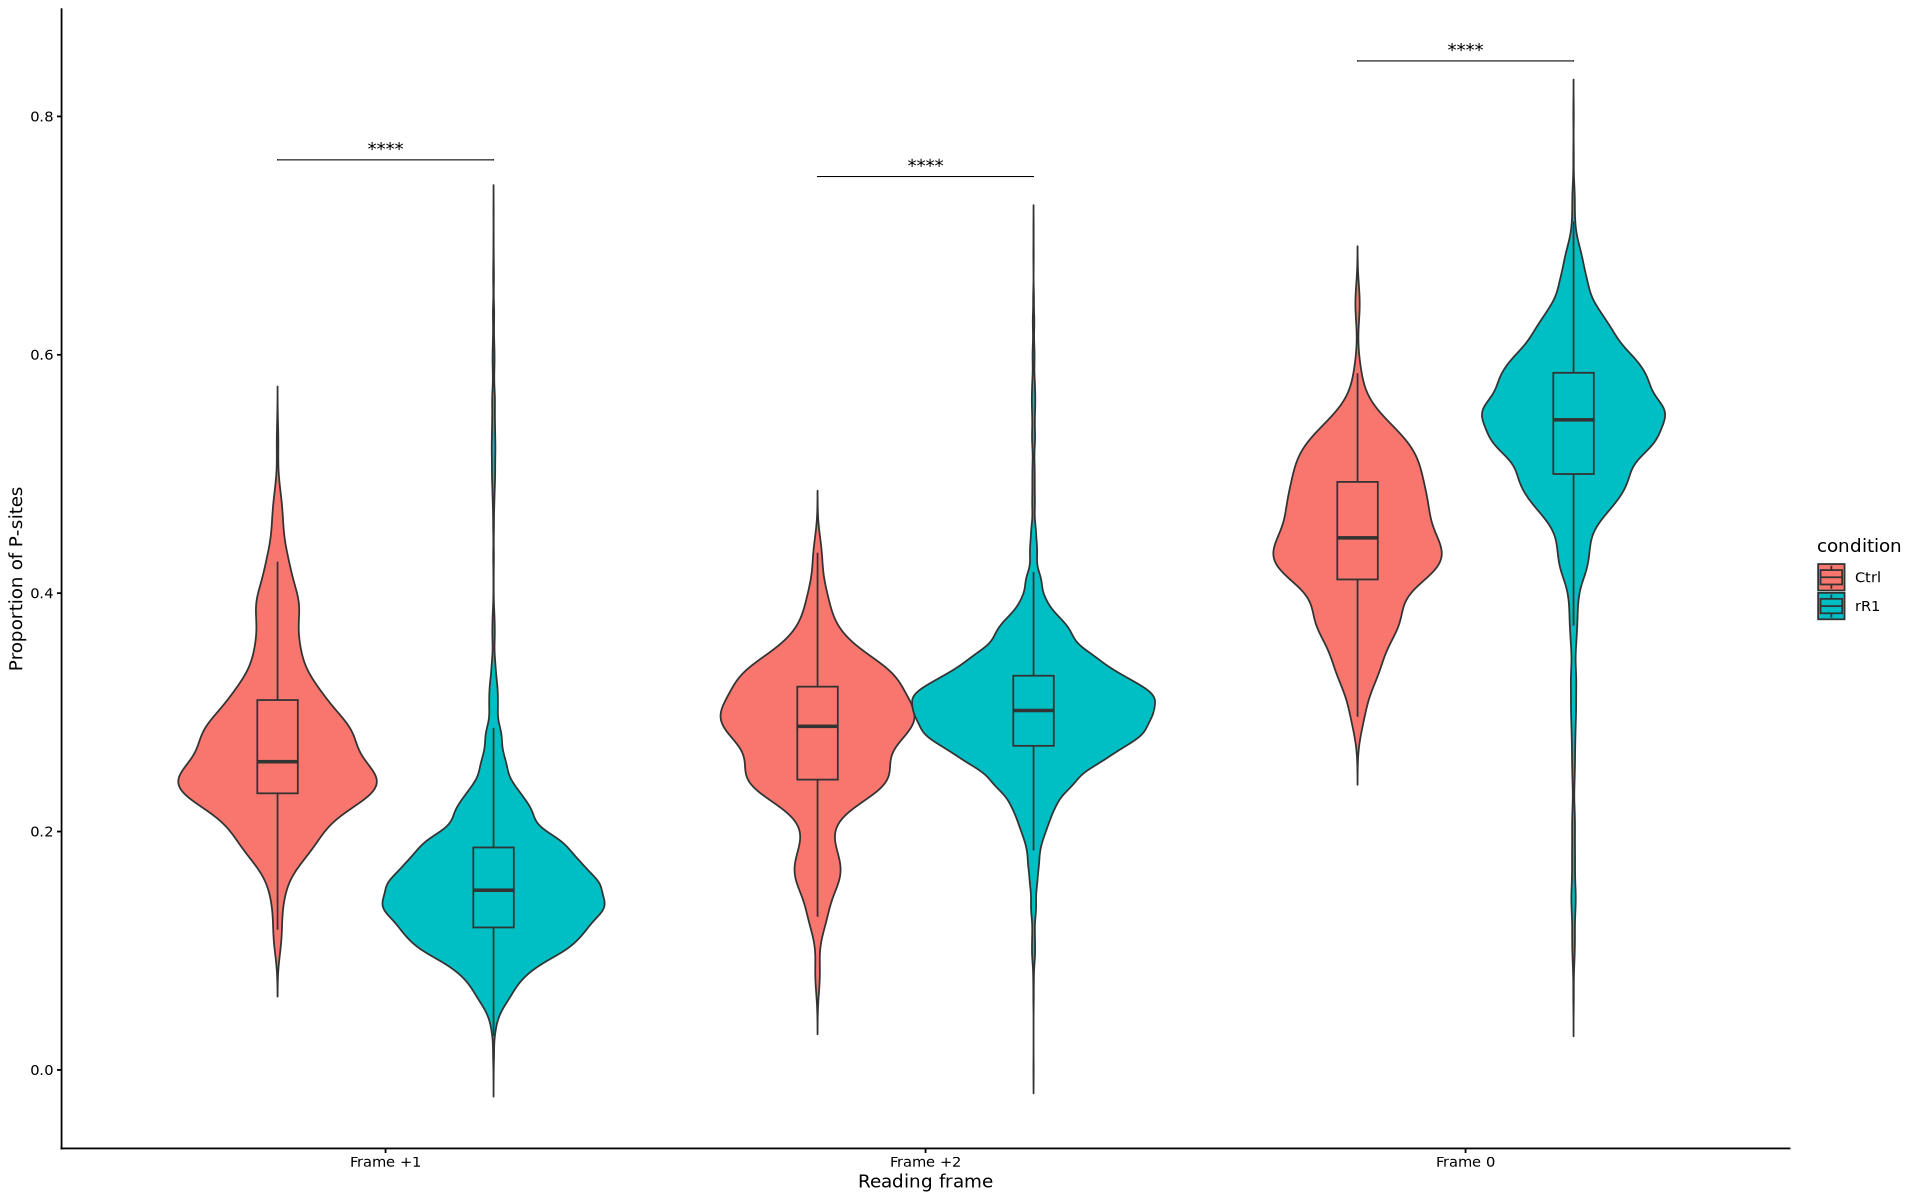

In [58]:
# computer the frame-0 fraction per transcript (per sample)
library(dplyr)


frame_tx <- psite_long %>%
 filter(psite_region == "cds") %>%   # critical
  group_by(sample_name, transcript) %>%
  summarise(
    total_psites = n(),
    prop_frame0 = mean(frame == 0),
    prop_frame1 = mean(frame == 1),
    prop_frame2 = mean(frame == 2),
    .groups = "drop"
  ) %>%
  filter(total_psites >= 50)

library(tidyr)

frame_tx_long <- frame_tx %>%
  pivot_longer(
    cols = starts_with("prop_frame"),
    names_to = "frame",
    values_to = "proportion"
  ) %>%
  mutate(
    frame = recode(
      frame,
      prop_frame0 = "Frame 0",
      prop_frame1 = "Frame +1",
      prop_frame2 = "Frame +2"
    )
  )


frame_tx_long <- frame_tx_long %>%
  mutate(condition = case_when(
    sample_name %in% c("extract_B73_1_1", "extract_B73_3_1") ~ "rR1",
    sample_name %in% c("extract_B73_2_1", "extract_B73_4_1") ~ "Ctrl"
  ))

library(rstatix)

stats <- frame_tx_long %>%
  group_by(frame) %>%
  wilcox_test(proportion ~ condition) %>%
  add_significance("p") %>%
  add_xy_position(x = "frame")



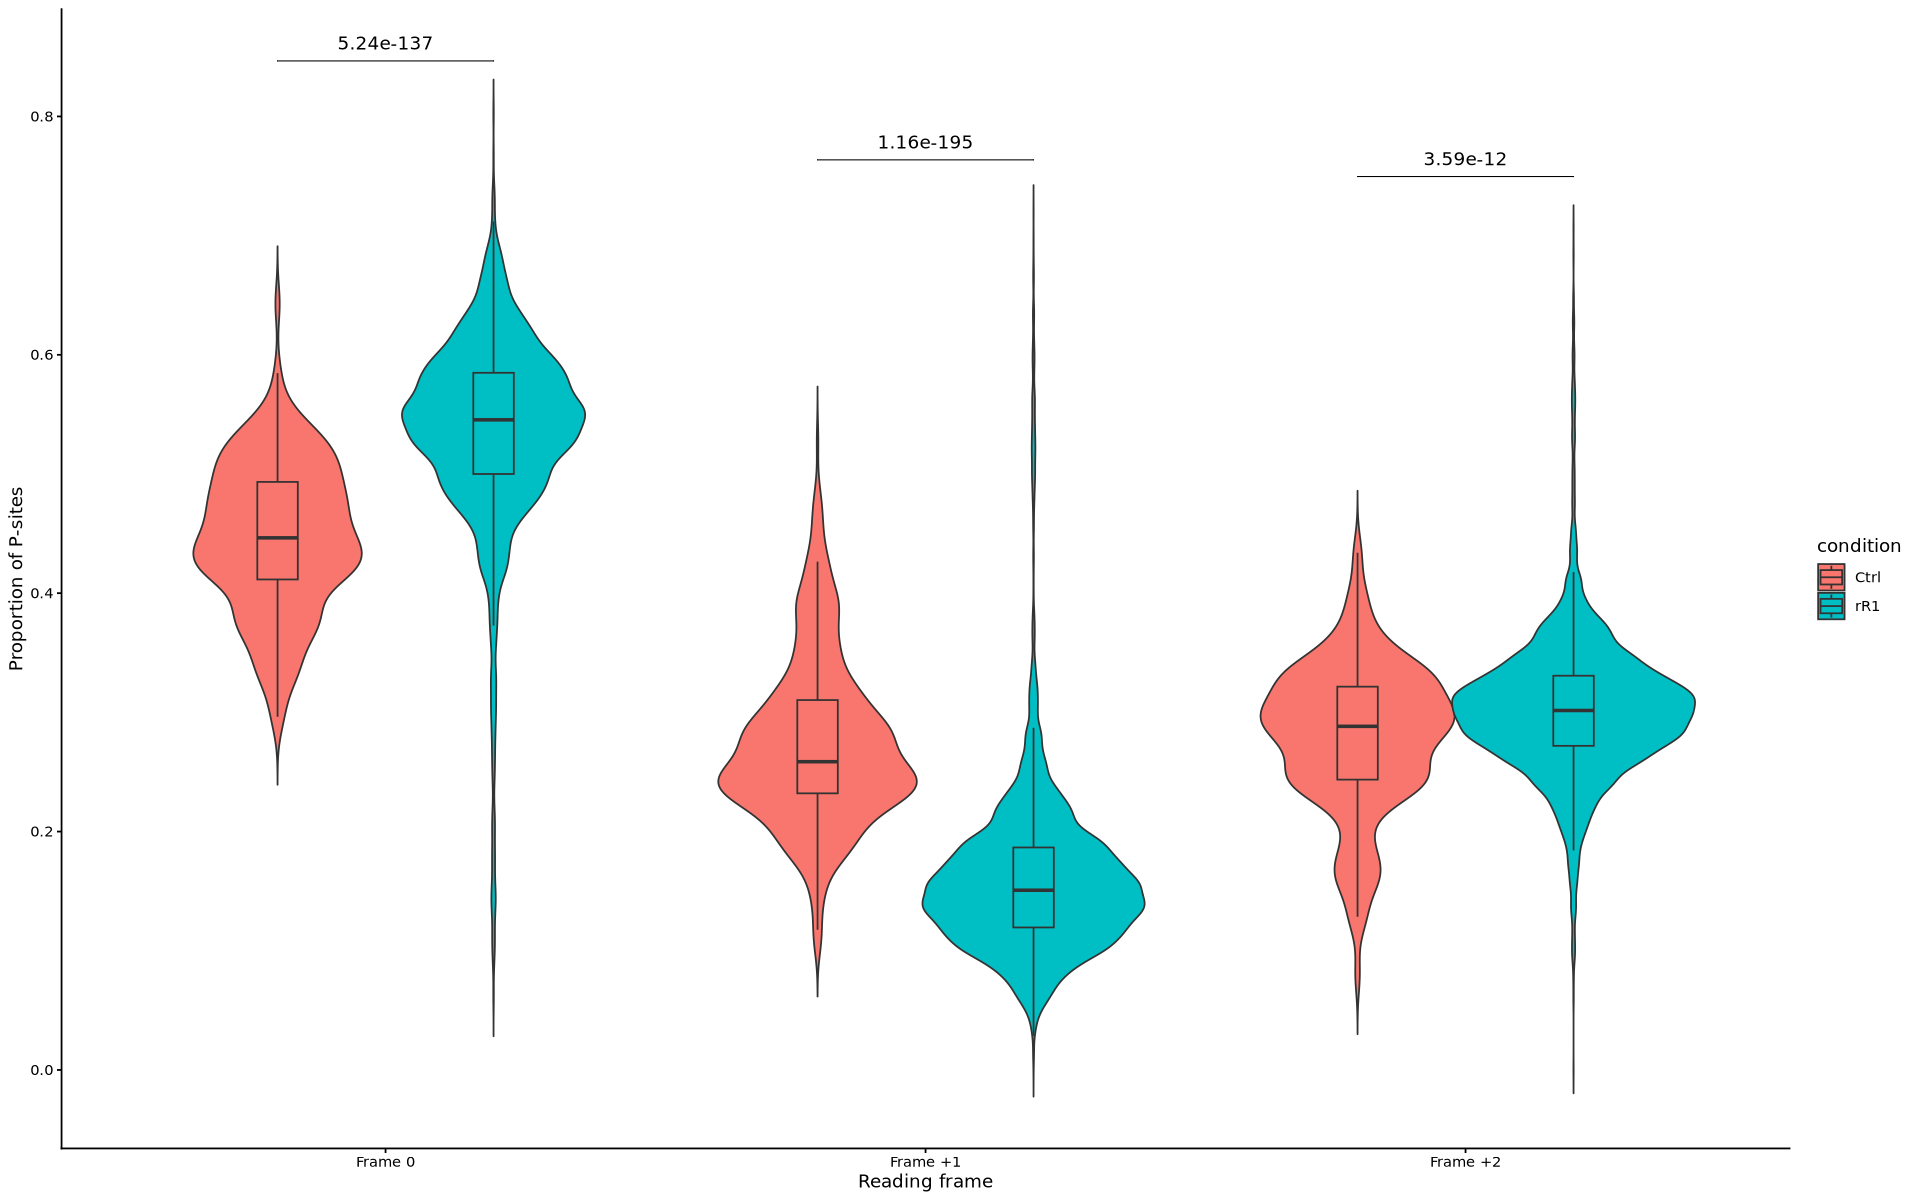

In [60]:
library(rstatix)
library(dplyr)

# Compute Wilcoxon test per frame
stats <- frame_tx_long %>%
  group_by(frame) %>%
  wilcox_test(proportion ~ condition)

stats <- stats %>%
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  mutate(p.label = signif(p.adj, 3))  # shorten for plot

frame_tx_long <- frame_tx_long %>%
  mutate(
    frame = factor(
      frame,
      levels = c("Frame 0", "Frame +1", "Frame +2")
    )
  )

library(ggpubr)

stats <- stats %>%
  add_xy_position(x = "frame", dodge = 0.8)

library(ggplot2)

ggplot(frame_tx_long, aes(frame, proportion, fill = condition)) +
  geom_violin(position = position_dodge(0.8), trim = FALSE) +
  geom_boxplot(
    width = 0.15,
    position = position_dodge(0.8),
    outlier.shape = NA
  ) +
  stat_pvalue_manual(
    stats,
    label = "p.label",   # show adjusted p-value
    tip.length = 0
  ) +
  ylab("Proportion of P-sites") +
  xlab("Reading frame") +
  theme_classic()


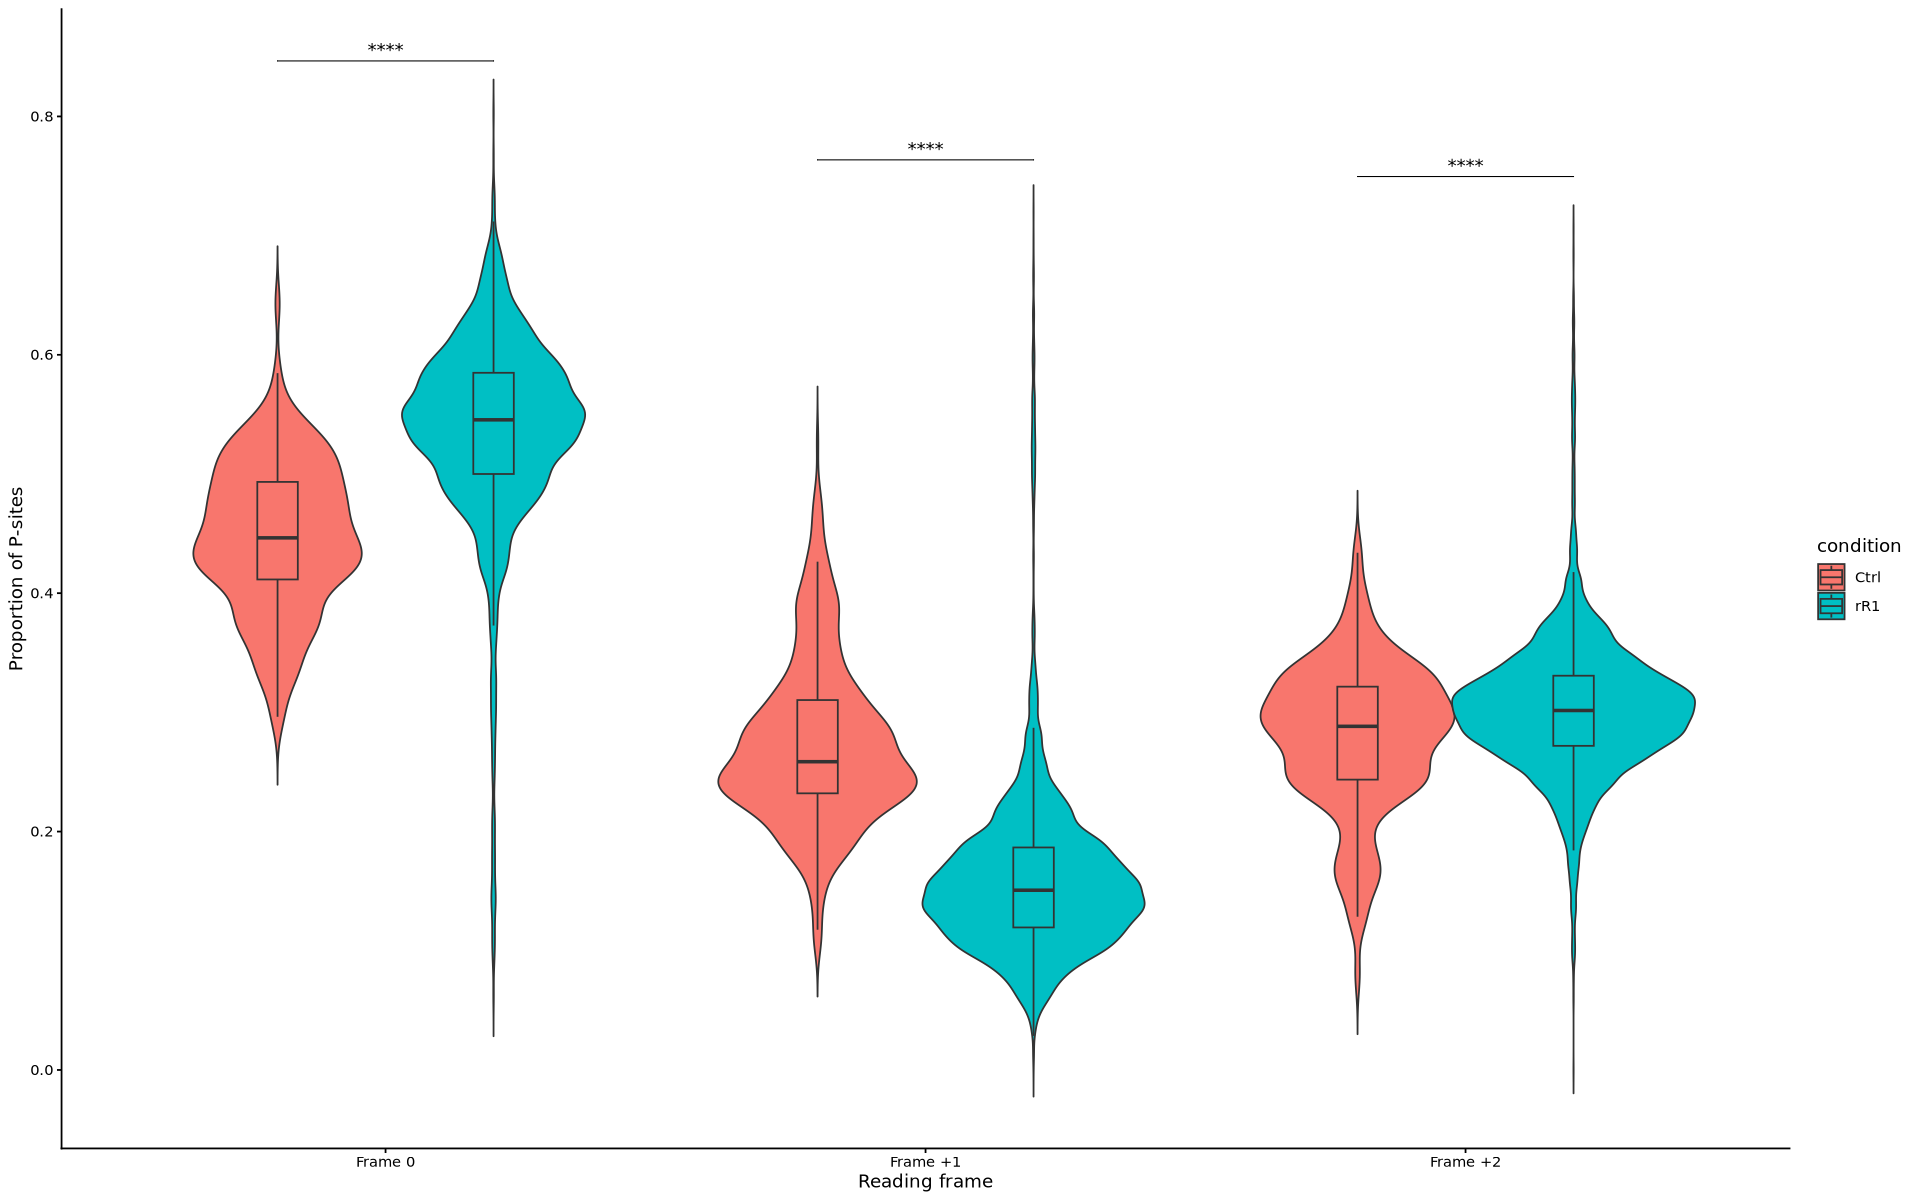

In [62]:
library(rstatix)
library(dplyr)
library(dplyr)
library(rstatix)

# Wilcoxon test per frame
stats <- frame_tx_long %>%
  group_by(frame) %>%
  wilcox_test(proportion ~ condition) %>%
  # Multiple testing correction across frames
  mutate(p.adj = p.adjust(p, method = "BH")) %>%
  # Convert adjusted p-values to significance stars
  add_significance("p.adj") %>%
  add_xy_position(x = "frame", dodge = 0.8)
frame_tx_long <- frame_tx_long %>%
  mutate(
    frame = factor(
      frame,
      levels = c("Frame 0", "Frame +1", "Frame +2")
    )
  )
library(ggplot2)
library(ggpubr)

# Make sure frame factor is in the right order
frame_tx_long <- frame_tx_long %>%
  mutate(frame = factor(frame, levels = c("Frame 0", "Frame +1", "Frame +2")))

ggplot(frame_tx_long, aes(frame, proportion, fill = condition)) +
  geom_violin(position = position_dodge(0.8), trim = FALSE) +
  geom_boxplot(
    width = 0.15,
    position = position_dodge(0.8),
    outlier.shape = NA
  ) +
  stat_pvalue_manual(
    stats,
    label = "p.adj.signif",  # stars instead of numeric p-values
    tip.length = 0
  ) +
  ylab("Proportion of P-sites") +
  xlab("Reading frame") +
  theme_classic()


In [346]:
library(Biostrings)

fa <- readDNAStringSet("gencode.vM35.transcripts.fa")

names(fa) <- sub("\\..*$", "", names(fa))   # remove .1 .2 .3
names(fa) <- sub("\\|.*$", "", names(fa))   # remove GENCODE junk

writeXStringSet(
  fa,
  filepath = "gencode.vM35.transcripts.clean.fa"
)


In [361]:
# Loop over all samples in reads_psite_list_th
reads_psite_list_th <- lapply(reads_psite_list_th, function(dt) {
  # Ensure transcript column is character
  dt[, transcript := as.character(transcript)]
  
  # Remove version numbers after the dot
  dt[, transcript := sub("\\..*$", "", transcript)]
  
  dt  # return modified data.table
})

In [363]:
reads_psite_list_th <- lapply(reads_psite_list_th, function(dt) {
  dt[, transcript := as.character(transcript)]
  dt
})

In [364]:
input_samples <- list("rR1 - rep1" = c("extract_B73_1_1"))

In [365]:
example_cu_barplot <- codon_usage_psite(
  reads_psite_list_th,
  cds,
  sample = input_samples,
  multisamples = "average",
  plot_style = "facet",
  #gtfpath = "/store24/project24/ladcol_002/riboseq/reference_genome/gencode.vM35.annotation.gtf",
  fastapath = "gencode.vM35.transcripts.clean.fa",
  fasta_genome = FALSE,
  frequency_normalization = FALSE
)


ERROR: Error in seq.default(quantile(dt$length, (1 - cl/100)/2), quantile(dt$length, : 'from' must be a finite number
